In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from itertools import product, combinations


import sys
import importlib


sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")

import current_measurements.src.src_current_measurement_simulations
importlib.reload(current_measurements.src.src_current_measurement_simulations);
from current_measurements.src.src_current_measurement_simulations import CurrentMeasurementSimulation

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector


from current_simulations.current_simulation import FockBasisState, convert_reduced_to_fock_state


# 1. Two Levels, no interactions

### 1.1 Initial detuned and resonant Hamiltonians for 0 and $\pi$ flux

In [4]:
def generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, J_parallel, U, frequencies):
    H = 0

    for i in range(num_qubits):
        a_i = annihilation_operators[i]
        H += frequencies[i] * a_i.dag() * a_i
        H += U / 2 * a_i.dag() * a_i * (a_i.dag() * a_i - 1)

        if i < num_qubits - 1:
            a_j = annihilation_operators[i + 1]
            H += J * (a_i.dag() * a_j + a_j.dag() * a_i)
        
        if i < num_qubits - 2:
            a_j = annihilation_operators[i + 2]
            H += J_parallel * (a_i.dag() * a_j + a_j.dag() * a_i)

    return H

In [5]:
num_levels = 2
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz

U = 180* 2 * np.pi  # in MHz

resonance_point = 4e3 * 2 * np.pi  # in MHz
detunings = np.linspace(-175, 175, num_qubits) * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

annihilation_operators = []
for i in range(num_qubits):
    op_list = []
    for j in range(num_qubits):
        if i == j:
            op_list.append(qt.destroy(num_levels))
        else:
            op_list.append(qt.qeye(num_levels))
    a_i = qt.tensor(op_list)
    annihilation_operators.append(a_i)

number_operators = [a.dag() * a for a in annihilation_operators]
total_number_operator = sum(number_operators)

H_detuned_0 = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, J, 0, frequencies)
H_resonant_0 = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, J, 0, [resonance_point]*num_qubits)

H_detuned_pi = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, -J, 0, frequencies)
H_resonant_pi = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, -J, 0, [resonance_point]*num_qubits)


label_to_Hamiltonian = {
    '0_flux_detuned': H_detuned_0,
    '0_flux_resonant': H_resonant_0,
    'pi_flux_detuned': H_detuned_pi,
    'pi_flux_resonant': H_resonant_pi
}

In [6]:
label_to_eigenvalues = {}
label_to_eigenstates = {}

In [7]:
for label in label_to_Hamiltonian:
    H = label_to_Hamiltonian[label]
    eigenvalues, eigenstates = H.eigenstates()
    label_to_eigenvalues[label] = eigenvalues
    label_to_eigenstates[label] = eigenstates

In [8]:
def get_eigenenergies_and_eigenstates(H, total_number_operator):

    eigenvalues, eigenstates = H.eigenstates()

    particle_number_to_eigenenergy_dict = {}
    particle_number_to_eigenstate_dict = {}

    for i in range(len(eigenvalues)):
        eigenstate = eigenstates[i]
        eigenenergy = eigenvalues[i]
        particle_number = int(round(qt.expect(total_number_operator, eigenstate)))

       

        if particle_number not in particle_number_to_eigenenergy_dict:
            particle_number_to_eigenenergy_dict[particle_number] = []
            particle_number_to_eigenstate_dict[particle_number] = []

        particle_number_to_eigenenergy_dict[particle_number].append(eigenenergy)
        particle_number_to_eigenstate_dict[particle_number].append(eigenstate)
    for particle_number in particle_number_to_eigenenergy_dict:
        energies = particle_number_to_eigenenergy_dict[particle_number]
        states = particle_number_to_eigenstate_dict[particle_number]

        sorted_indices = np.argsort(energies)
        sorted_energies = np.array([energies[i] for i in sorted_indices])
        sorted_states = np.array([states[i] for i in sorted_indices], dtype=object)

        particle_number_to_eigenenergy_dict[particle_number] = sorted_energies
        particle_number_to_eigenstate_dict[particle_number] = sorted_states

    return particle_number_to_eigenenergy_dict, particle_number_to_eigenstate_dict

In [9]:
label_to_particle_number_eigenenergy_dict = {}
label_to_particle_number_eigenstate_dict = {}

for label in label_to_Hamiltonian:
    
    label_to_particle_number_eigenenergy_dict[label], label_to_particle_number_eigenstate_dict[label] = get_eigenenergies_and_eigenstates(label_to_Hamiltonian[label], total_number_operator)

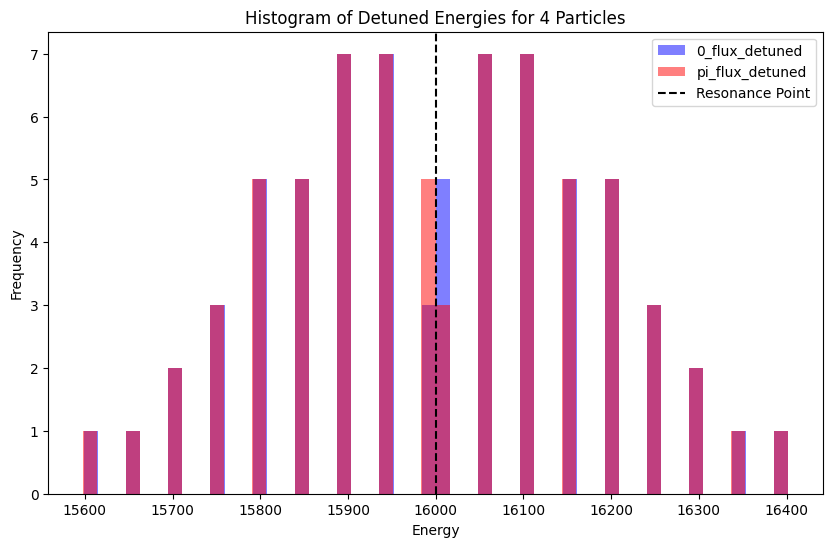

In [10]:
### plot detuned energies as histograms for 4 particles

### note that they should be exactly the negatives of each other

plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_detuned', 'pi_flux_detuned'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Detuned Energies for 4 Particles')
plt.legend()
plt.show()

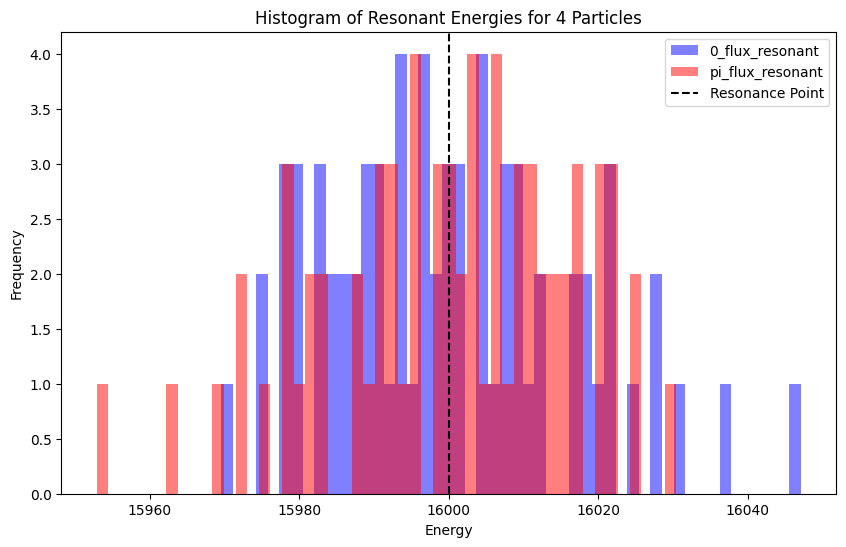

In [11]:
### plot the resonant energies as histograms for 4 particles
plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_resonant', 'pi_flux_resonant'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')


plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Resonant Energies for 4 Particles')
plt.legend()
plt.show()

### 1.2 Global X-rotation

In [12]:
x_rotation_operator = qt.tensor([qt.sigmax() for _ in range(num_qubits)])

label_to_Hamiltonian_after_x_rotation = {}
label_to_particle_number_eigenenergy_dict_after_x_rotation = {}
label_to_particle_number_eigenstate_dict_after_x_rotation = {}

for label in label_to_Hamiltonian:
    H = label_to_Hamiltonian[label]
    H_rotated = x_rotation_operator * H * x_rotation_operator.dag()
    label_to_Hamiltonian_after_x_rotation[label] = H_rotated

    label_to_particle_number_eigenenergy_dict_after_x_rotation[label], label_to_particle_number_eigenstate_dict_after_x_rotation[label] = get_eigenenergies_and_eigenstates(H_rotated, total_number_operator)

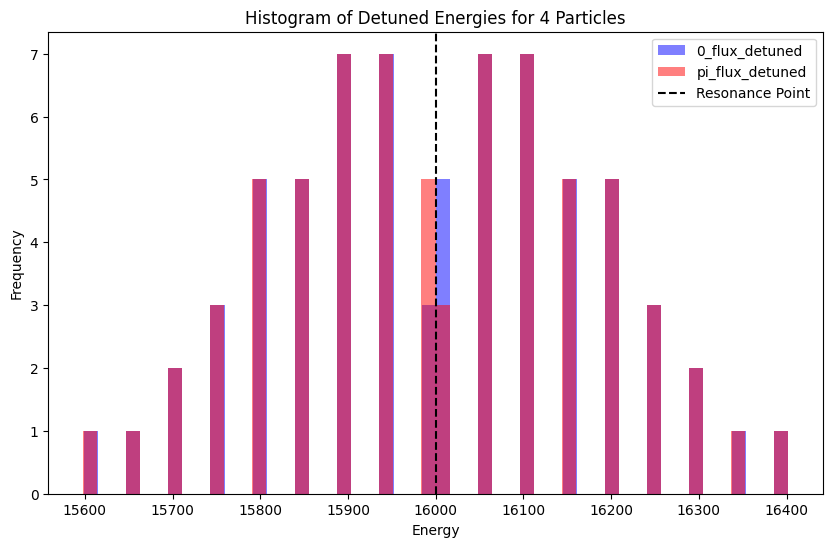

In [13]:
### plot detuned energies as histograms for 4 particles

### note that they should be exactly the negatives of each other

plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_detuned', 'pi_flux_detuned'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict_after_x_rotation[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Detuned Energies for 4 Particles')
plt.legend()
plt.show()

#### 1.2.2 Let's analyze the highest eigenstate at half filling of pi flux

In [14]:
label = 'pi_flux_detuned'
eigenstate_highest_detuned = label_to_particle_number_eigenstate_dict[label][num_particles][-1]
eigenstate_lowest_detuned = label_to_particle_number_eigenstate_dict[label][num_particles][0]

eigenstate_highest_detuned_x_rotation = label_to_particle_number_eigenstate_dict_after_x_rotation[label][num_particles][-1]
eigenstate_lowest_detuned_x_rotation = label_to_particle_number_eigenstate_dict_after_x_rotation[label][num_particles][0]

eigenstate_highest_detuned_flipped = x_rotation_operator * eigenstate_highest_detuned


eigenstate_highest_detuned_0_flux = label_to_particle_number_eigenstate_dict['0_flux_detuned'][num_particles][-1]


In [15]:
basis = list(product(range(num_levels), repeat=num_qubits))

In [16]:
print('\t\t\t\t h\t l\t hx \t Hx \t 0f \t')

state_list = [eigenstate_highest_detuned, eigenstate_lowest_detuned, eigenstate_highest_detuned_flipped, eigenstate_highest_detuned_x_rotation, eigenstate_highest_detuned_0_flux]
H_det_pi = label_to_Hamiltonian['pi_flux_detuned']
H_det_pi_x = label_to_Hamiltonian_after_x_rotation['pi_flux_detuned']

print('H_det_pi energy\t\t\t', *[str(round(qt.expect(H_det_pi, state/2/np.pi))) + '\t' for state in state_list])
print('H_det_pi_x energy\t\t', *[str(round(qt.expect(H_det_pi_x, state/2/np.pi))) + '\t' for state in state_list])

for i in range(len(eigenstate_highest_detuned.full())):
    if sum(basis[i]) == num_particles:
        print(basis[i], '\t', *[str(round(np.power(state.full()[i][0].real, 2), 3)) + '\t' for state in state_list])

				 h	 l	 hx 	 Hx 	 0f 	
H_det_pi energy			 2610	 2483	 2483	 2483	 2610	
H_det_pi_x energy		 2483	 2609	 2610	 2610	 2483	
(0, 0, 0, 0, 1, 1, 1, 1) 	 0.983	 0.0	 0.0	 0.0	 0.973	
(0, 0, 0, 1, 0, 1, 1, 1) 	 0.011	 0.0	 0.0	 0.0	 0.017	
(0, 0, 0, 1, 1, 0, 1, 1) 	 0.003	 0.0	 0.0	 0.0	 0.005	
(0, 0, 0, 1, 1, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 0, 1, 1, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 0, 0, 1, 1, 1) 	 0.003	 0.0	 0.0	 0.0	 0.005	
(0, 0, 1, 0, 1, 0, 1, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 0, 1, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 0, 1, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 0, 0, 1, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 0, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 0, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 1, 0, 0, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 1, 0, 1, 0) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 0, 1, 1, 1, 1, 0, 0) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 1, 0, 0, 0, 1, 1, 1) 	 0.0	 0.0	 0.0	 0.0	 0.0	
(0, 1, 0, 0, 1, 0, 1, 1) 	 

In [17]:
### construct negative Hamiltonian explicitly

negative_H_detuned_pi = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, -J, 0, -frequencies) + sum(frequencies)

particle_number_to_eigenenergy_dict_neg, particle_number_to_eigenstate_dict_neg = get_eigenenergies_and_eigenstates(negative_H_detuned_pi, total_number_operator)

print(particle_number_to_eigenenergy_dict_neg[num_particles]/2/np.pi)

[15598.37608357 15648.75325798 15698.21099468 15698.57531056
 15748.81020366 15748.8229798  15749.09415611 15798.0288425
 15799.20223557 15799.2466327  15799.36922121 15799.36969425
 15848.95468377 15849.16007795 15849.47321868 15849.75318715
 15849.75319945 15898.48142651 15898.49719432 15899.34996348
 15899.3516733  15899.88402338 15899.88481819 15900.27723223
 15949.15895343 15949.44243836 15949.69395486 15949.69401564
 15950.36333124 15950.52923774 15950.53373078 15999.1055986
 15999.4865444  15999.6110704  15999.66327266 15999.6632769
 16000.5197805  16000.52316463 16000.78735999 16048.96279687
 16050.32172768 16050.41170461 16050.46466052 16050.46491414
 16050.66435132 16050.93229379 16099.78635328 16099.78864447
 16100.13848434 16100.14295801 16100.70280144 16100.71106953
 16101.68319361 16150.4114517  16150.41149438 16150.68644247
 16151.33480841 16151.39813525 16200.12061088 16200.12132306
 16200.83280551 16201.30423414 16201.41487524 16251.00559487
 16251.01854344 16251.88957

In [18]:
negative_H_detuned_0 = -label_to_Hamiltonian['0_flux_detuned'] + sum(frequencies)

particle_number_to_eigenenergy_dict_neg_0, particle_number_to_eigenstate_dict_neg_0 = get_eigenenergies_and_eigenstates(negative_H_detuned_0, total_number_operator)

print(particle_number_to_eigenenergy_dict_neg_0[num_particles]/2/np.pi)


[15598.37608357 15648.75325798 15698.21099468 15698.57531056
 15748.81020366 15748.8229798  15749.09415611 15798.0288425
 15799.20223557 15799.2466327  15799.36922121 15799.36969425
 15848.95468377 15849.16007795 15849.47321868 15849.75318715
 15849.75319945 15898.48142651 15898.49719432 15899.34996348
 15899.3516733  15899.88402338 15899.88481819 15900.27723223
 15949.15895343 15949.44243836 15949.69395486 15949.69401564
 15950.36333124 15950.52923774 15950.53373078 15999.1055986
 15999.4865444  15999.6110704  15999.66327266 15999.6632769
 16000.5197805  16000.52316463 16000.78735999 16048.96279687
 16050.32172768 16050.41170461 16050.46466052 16050.46491414
 16050.66435132 16050.93229379 16099.78635328 16099.78864447
 16100.13848434 16100.14295801 16100.70280144 16100.71106953
 16101.68319361 16150.4114517  16150.41149438 16150.68644247
 16151.33480841 16151.39813525 16200.12061088 16200.12132306
 16200.83280551 16201.30423414 16201.41487524 16251.00559487
 16251.01854344 16251.88957

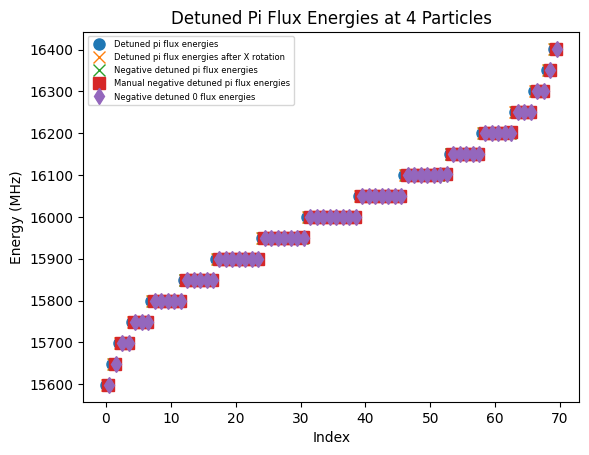

In [19]:
indices = np.array(list(range(len(energies))))

### this plotting method works best for <= 4 qubits


# pi flux detuned Hamiltonian
energies = label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles]/2/np.pi
plt.plot(indices, energies, 'o', linestyle='', markersize=8, label='Detuned pi flux energies')

# pi flux detuned Hamiltonian after x rotation
energies = label_to_particle_number_eigenenergy_dict_after_x_rotation['pi_flux_detuned'][num_particles]/2/np.pi
plt.plot(indices + 0.125, energies, 'x', linestyle='', markersize=8, label='Detuned pi flux energies after X rotation')

# negative Hamiltonian (should match pi flux detuned after x rotation)
energies = particle_number_to_eigenenergy_dict_neg[num_particles]/2/np.pi
plt.plot(indices + 0.25, energies, 'x', linestyle='', markersize=8, label='Negative detuned pi flux energies')

# manual negative and offset - this doesn't work because switching J_|| --> -J_|| changes the spectrum
energies = -label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles]/2/np.pi + sum(frequencies)/2/np.pi
energies = sorted(energies)
plt.plot(indices + 0.375, energies, 's', linestyle='', markersize=8, label='Manual negative detuned pi flux energies')

# negative 0 flux Hamiltonian (should match pi flux detuned)
energies = particle_number_to_eigenenergy_dict_neg_0[num_particles]/2/np.pi
plt.plot(indices + 0.5, energies, 'd', linestyle='', markersize=8, label='Negative detuned 0 flux energies')


plt.xlabel('Index')
plt.ylabel('Energy (MHz)')
plt.title('Detuned Pi Flux Energies at 4 Particles')
plt.legend(fontsize=6)
plt.show()

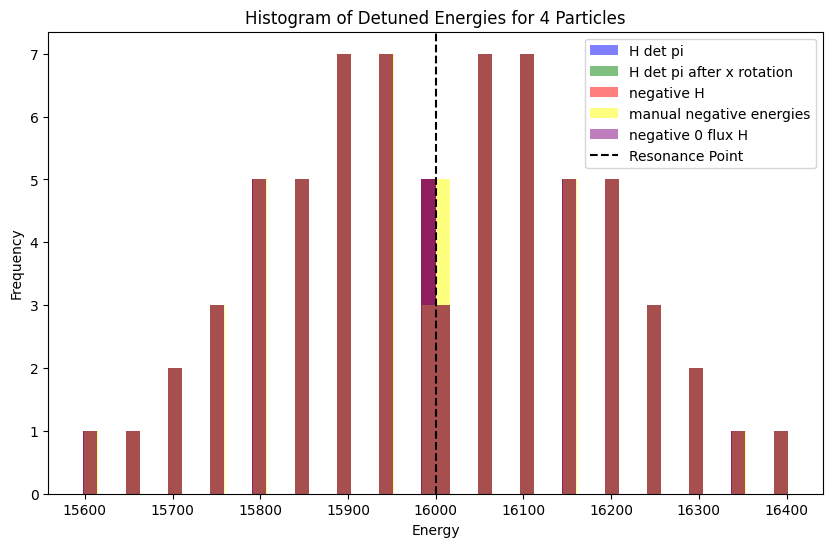

In [20]:
### plot detuned energies as histograms for 4 particles

### note that they should be exactly the negatives of each other

plt.figure(figsize=(10, 6))

# pi flux detuned Hamiltonian
energies = label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles]/2/np.pi
plt.hist(energies, bins=50, alpha=0.5, label='H det pi', color='blue')

# pi flux detuned after x rotation
energies = label_to_particle_number_eigenenergy_dict_after_x_rotation['pi_flux_detuned'][num_particles]/2/np.pi
plt.hist(energies, bins=50, alpha=0.5, label='H det pi after x rotation', color='green')

# negative Hamiltonian (should match pi flux detuned after x rotation)
energies = particle_number_to_eigenenergy_dict_neg[num_particles]/2/np.pi
plt.hist(energies, bins=50, alpha=0.5, label='negative H', color='red')

# manual negative and offset - this doesn't work because switching J_|| --> -J_|| changes the spectrum
energies = -label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles]/2/np.pi + sum(frequencies)/2/np.pi
plt.hist(energies, bins=50, alpha=0.5, label='manual negative energies', color='yellow')

# negative 0 flux Hamiltonian (should match pi flux detuned)
energies = particle_number_to_eigenenergy_dict_neg_0[num_particles]/2/np.pi
plt.hist(energies, bins=50, alpha=0.5, label='negative 0 flux H', color='purple')


plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Detuned Energies for 4 Particles')
plt.legend()
plt.show()

In [21]:
# let's check how the hamiltonians act on specific states

# first verify highest eigenstate pi and lowest eigenstate pi are related by x rotation
print('Checking highest eigenstate pi and lowest eigenstate pi relation by x rotation')
overlap = abs((eigenstate_highest_detuned_flipped.dag() * eigenstate_lowest_detuned))**2
print('Overlap:', np.round(overlap, 6))

print()
print(f'reference')
print(f'highest pi detuned energy: {np.round(label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles][-1]/2/np.pi, 3)} MHz')
print(f'lowest pi detuned energy: {np.round(label_to_particle_number_eigenenergy_dict['pi_flux_detuned'][num_particles][0]/2/np.pi, 3)} MHz')
print()

### h detuned pi and highest eignestate pi

print('Checking H detuned pi and highest eigenstate pi flux')
print(np.round(qt.expect(label_to_Hamiltonian['pi_flux_detuned'], eigenstate_highest_detuned)/2/np.pi, 3))
print()

print('Checking H detuned pi after x rotation and highest eigenstate pi flux')
print(np.round(qt.expect(label_to_Hamiltonian_after_x_rotation['pi_flux_detuned'], eigenstate_lowest_detuned)/2/np.pi, 3))
print()

print('Checking negative H detuned pi construction and lowest eigenstate pi flux')
print(np.round(qt.expect(negative_H_detuned_pi, eigenstate_lowest_detuned)/2/np.pi, 3))
print()

print('Checking H detuned 0 flux and lowest eigenstate pi flux')
print(np.round(qt.expect(label_to_Hamiltonian['0_flux_detuned'], eigenstate_lowest_detuned)/2/np.pi, 3))
print()


Checking highest eigenstate pi and lowest eigenstate pi relation by x rotation
Overlap: 0.916321

reference
highest pi detuned energy: 16401.282 MHz
lowest pi detuned energy: 15598.376 MHz

Checking H detuned pi and highest eigenstate pi flux
16401.282

Checking H detuned pi after x rotation and highest eigenstate pi flux
16394.745

Checking negative H detuned pi construction and lowest eigenstate pi flux
16394.745

Checking H detuned 0 flux and lowest eigenstate pi flux
15601.648



In [22]:
precision = 5
for i in range(len(basis)):
    if sum(basis[i]) == num_particles:
        print(basis[i], '\t', str(round(np.power(eigenstate_lowest_detuned.full()[i][0].real, 2), precision)) + 
              '\t', str(round(np.power(eigenstate_highest_detuned_flipped.full()[i][0].real, 2), precision)) + 
              '\t', str(round(np.power(eigenstate_highest_detuned.full()[i][0].real, 2), precision)) + 
              '\t', str(round(np.power(label_to_particle_number_eigenstate_dict['0_flux_detuned'][num_particles][0].full()[i][0].real, 2), precision)))

(0, 0, 0, 0, 1, 1, 1, 1) 	 0.0	 0.0	 0.98316	 0.0
(0, 0, 0, 1, 0, 1, 1, 1) 	 0.0	 0.0	 0.01101	 0.0
(0, 0, 0, 1, 1, 0, 1, 1) 	 0.0	 0.0	 0.00286	 0.0
(0, 0, 0, 1, 1, 1, 0, 1) 	 0.0	 0.0	 4e-05	 0.0
(0, 0, 0, 1, 1, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 0, 0, 1, 1, 1) 	 0.0	 0.0	 0.00286	 0.0
(0, 0, 1, 0, 1, 0, 1, 1) 	 0.0	 0.0	 2e-05	 0.0
(0, 0, 1, 0, 1, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 0, 1, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 1, 0, 0, 1, 1) 	 0.0	 0.0	 1e-05	 0.0
(0, 0, 1, 1, 0, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 1, 0, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 1, 1, 0, 0, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 1, 1, 0, 1, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 0, 1, 1, 1, 1, 0, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 0, 0, 1, 1, 1) 	 0.0	 0.0	 4e-05	 0.0
(0, 1, 0, 0, 1, 0, 1, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 0, 1, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 0, 1, 1, 1, 0) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 1, 0, 0, 1, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 1, 0, 1, 0, 1) 	 0.0	 0.0	 0.0	 0.0
(0, 1, 0, 

In [23]:
### calcultae current correlations with current operators

current_operators = []
for i in range(len(annihilation_operators)-1):
    a_i = annihilation_operators[i]
    a_j = annihilation_operators[i + 1]
    j_ij = 1j * J * (a_i.dag() * a_j - a_j.dag() * a_i)
    current_operators.append(j_ij)

# assume 1234
current_correlator = current_operators[0] * current_operators[2]

for labels in ['0_flux_resonant', 'pi_flux_resonant']:
    eigenstates = label_to_particle_number_eigenstate_dict[labels][num_particles]


    highest = eigenstates[-1]
    lowest = eigenstates[0]


    currents_highest = [qt.expect(current_operators[i], highest) for i in range(len(current_operators))]
    currents_lowest = [qt.expect(current_operators[i], lowest) for i in range(len(current_operators))]

    correlation_highest = qt.expect(current_correlator, highest) - currents_highest[0] * currents_highest[2]
    correlation_lowest = qt.expect(current_correlator, lowest) - currents_lowest[0] * currents_lowest[2]

    print(f'Current correlations for {labels} Hamiltonian:')
    print(f'Highest energy state: {np.round(correlation_highest/J/J, 6)}')
    print(f'Lowest energy state: {np.round(correlation_lowest/J/J, 6)}')
    print()

Current correlations for 0_flux_resonant Hamiltonian:
Highest energy state: 0.067826
Lowest energy state: 0.318347

Current correlations for pi_flux_resonant Hamiltonian:
Highest energy state: 0.318347
Lowest energy state: 0.067826



In [24]:
### calculate corrent correlations with fock state representation
basis = list(product(range(num_levels), repeat=num_qubits))

lowest_pi_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][0])
highest_pi_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][-1])

lowest_0_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['0_flux_resonant'][num_particles][0])
highest_0_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['0_flux_resonant'][num_particles][-1])


print(get_current_correlation(lowest_pi_fock, J, J, 1, 2, 3, 4))
print(get_current_correlation(highest_pi_fock, J, J, 1, 2, 3, 4))

print(get_current_correlation(lowest_0_fock, J, J, 1, 2, 3, 4))
print(get_current_correlation(highest_0_fock, J, J, 1, 2, 3, 4))


NameError: name 'get_current_correlation' is not defined

### 2.3 Testing

In [25]:
### print matrix elements of (1,1,1,1,0,0,0,0) state for pi flux resonant

basis = list(product(range(num_levels), repeat=num_qubits))

H = label_to_Hamiltonian['pi_flux_resonant']

index = -1
for i in range(len(basis)):
    if basis[i] == (1,1,1,1,0,0,0,0):
        index = i
        break

for i in range(len(basis)):
    state = basis[i]
    matrix_element = H[index,i]
    if abs(matrix_element) > 1e-6:
        print(f'{basis[index]} to {state}: {matrix_element/2/np.pi}')


(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 0, 1, 1, 0, 0, 0): (-6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 0, 0, 1, 0, 0): (-6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 0, 1, 0, 0, 0): (6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 1, 0, 0, 0, 0): (16000+0j)


In [26]:
from collections import Counter

# verify full_to_reduced_index_map is a bijection

# verify full_to_reduced_index_map is bijection

values = list(full_to_reduced_index_map.values())
keys = list(full_to_reduced_index_map.keys())

# check injective (no duplicate reduced indices)
if len(set(values)) == len(values):
    print("Injective: all reduced indices are unique")
else:
    dupes = [v for v,count in Counter(values).items() if count > 1]
    print("Not injective. Duplicated reduced indices:", sorted(dupes))

# check surjective onto contiguous range 0..N-1
N = len(values)
expected = set(range(N))
missing = expected - set(values)
extra = set(values) - expected

if missing:
    print("Not surjective onto 0..N-1. Missing indices:", sorted(missing))
else:
    print("Surjective onto 0..N-1")

if extra:
    print("Values outside expected range 0..N-1:", sorted(extra))

# build inverse map and verify round-trip
inverse_map = {v: k for k, v in full_to_reduced_index_map.items()}
round_trip_ok = True
for full_idx, reduced_idx in full_to_reduced_index_map.items():
    if inverse_map.get(reduced_idx) != full_idx:
        round_trip_ok = False
        print(f"Round-trip mismatch for full index {full_idx} -> reduced {reduced_idx} -> {inverse_map.get(reduced_idx)}")
        break

print("Inverse round-trip check:", round_trip_ok)

# final verdict
if len(set(values)) == len(values) and not missing and round_trip_ok:
    print(f"full_to_reduced_index_map is bijective (maps {len(keys)} full indices to 0..{N-1})")
else:
    print("full_to_reduced_index_map is NOT bijective")

NameError: name 'full_to_reduced_index_map' is not defined

In [27]:
### create submatrix of H for 4 particle, single occupation states only
basis = list(product(range(num_levels), repeat=num_qubits))
full_to_reduced_index_map = {}
for i in range(len(basis)):
    if sum(basis[i]) == num_particles and np.all(np.array(basis[i]) <= 1):
        reduced_index = len(full_to_reduced_index_map)
        full_to_reduced_index_map[i] = reduced_index

H_reduced_1 = np.zeros((70, 70), dtype=complex)
for i in range(len(basis)):
    if sum(basis[i]) == num_particles and np.all(np.array(basis[i]) <= 1):
        reduced_i = full_to_reduced_index_map[i]
        for j in range(len(basis)):
            if sum(basis[j]) == num_particles and np.all(np.array(basis[j]) <= 1):
                reduced_j = full_to_reduced_index_map[j]
                H_reduced_1[reduced_i, reduced_j] = H[i,j]
                # if abs(H[i,j]) > 1e-6:
                #     print(f'{basis[i]} to {basis[j]}: {H[i,j]/2/np.pi}')

In [28]:

# Verify H_reduced_1 is Hermitian

diff = H_reduced_1 - H_reduced_1.conj().T
max_abs_diff = np.max(np.abs(diff))
is_hermitian = np.allclose(H_reduced_1, H_reduced_1.conj().T, atol=1e-10, rtol=1e-8)

print("Hermitian:", is_hermitian)
print("Max |H - H†| =", max_abs_diff)

# Also check eigenvalues have negligible imaginary parts
eigvals = np.linalg.eigvals(H_reduced_1)
print("Max |Im(eigenvals)| =", np.max(np.abs(np.imag(eigvals))))

Hermitian: True
Max |H - H†| = 0.0
Max |Im(eigenvals)| = 0.0


In [29]:
### print coefficients of pi resonant eigenstates

eigenstates = label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles]

eigenstate_highest = eigenstates[-1]
eigenstate_lowest = eigenstates[0]

print(f'\t\t\t\t lowest\t\t highest')
for i in range(len(basis)):
    state = basis[i]
    if sum(basis[i]) == num_particles and np.all(np.array(basis[i]) <= 1):
        print(f'{state}:\t {np.round(eigenstate_lowest[i][0].real, 3)}\t\t{np.round(eigenstate_highest[i][0].real, 3)}')

				 lowest		 highest
(0, 0, 0, 0, 1, 1, 1, 1):	 -0.021		0.005
(0, 0, 0, 1, 0, 1, 1, 1):	 0.037		-0.038
(0, 0, 0, 1, 1, 0, 1, 1):	 -0.066		-0.032
(0, 0, 0, 1, 1, 1, 0, 1):	 0.069		0.067
(0, 0, 0, 1, 1, 1, 1, 0):	 -0.064		0.076
(0, 0, 1, 0, 0, 1, 1, 1):	 -0.066		-0.032
(0, 0, 1, 0, 1, 0, 1, 1):	 0.086		0.026
(0, 0, 1, 0, 1, 1, 0, 1):	 -0.108		0.031
(0, 0, 1, 0, 1, 1, 1, 0):	 0.097		-0.014
(0, 0, 1, 1, 0, 0, 1, 1):	 -0.133		0.105
(0, 0, 1, 1, 0, 1, 0, 1):	 0.13		-0.099
(0, 0, 1, 1, 0, 1, 1, 0):	 -0.145		-0.173
(0, 0, 1, 1, 1, 0, 0, 1):	 -0.14		-0.148
(0, 0, 1, 1, 1, 0, 1, 0):	 0.118		-0.074
(0, 0, 1, 1, 1, 1, 0, 0):	 -0.102		0.097
(0, 1, 0, 0, 0, 1, 1, 1):	 0.069		0.067
(0, 1, 0, 0, 1, 0, 1, 1):	 -0.108		0.031
(0, 1, 0, 0, 1, 1, 0, 1):	 0.134		-0.127
(0, 1, 0, 0, 1, 1, 1, 0):	 -0.125		-0.126
(0, 1, 0, 1, 0, 0, 1, 1):	 0.13		-0.099
(0, 1, 0, 1, 0, 1, 0, 1):	 -0.127		0.057
(0, 1, 0, 1, 0, 1, 1, 0):	 0.144		0.119
(0, 1, 0, 1, 1, 0, 0, 1):	 0.16		0.188
(0, 1, 0, 1, 1, 0, 1, 0):	 -0.139		0.14

In [30]:
### verify H_reduced_1 is invariant under global x rotation
# this can be implemented by reversing rows and columns of H_reduced_1

H_reduced_1_flipped = H_reduced_1[::-1, ::-1]

diff = H_reduced_1 - H_reduced_1_flipped
max_abs_diff = np.max(np.abs(diff))

is_invariant = np.allclose(H_reduced_1, H_reduced_1_flipped, atol=1e-10, rtol=1e-8)
print("Invariant under global X rotation:", is_invariant)
print("Max |H - H_flipped| =", max_abs_diff)

Invariant under global X rotation: True
Max |H - H_flipped| = 0.0


In [31]:
### diagonalize H_reduced_1 and compare to eigenvalues from full H

eigenvalues_reduced, eigenstates_reduced = np.linalg.eigh(H_reduced_1)
eigenstates_reduced = eigenstates_reduced.T

eigenvalues_full = label_to_particle_number_eigenenergy_dict['pi_flux_resonant'][num_particles]

compare_eigenvalues = False
if compare_eigenvalues:
    print('Comparing eigenvalues from reduced H to full H:')
    for i in range(len(eigenvalues_reduced)):
        ev_reduced = eigenvalues_reduced[i]
        ev_full = eigenvalues_full[i]
        print(f'Index {i}: Reduced: {np.round(ev_reduced/2/np.pi, 6)} MHz, Full: {np.round(ev_full/2/np.pi, 6)} MHz, Diff: {np.round((ev_reduced - ev_full)/2/np.pi, 6)} MHz')


# compare lowest and highest eigenstates
basis_reduced = [state for state in basis if sum(state) == num_particles]

precision = 3
print(f'\t\t\t\t lowest_r\t lowest\t highest_r \t highest')
for i in range(len(basis_reduced)):
    state = basis_reduced[i]
    reduced_index = i
    full_index = list(full_to_reduced_index_map.keys())[list(full_to_reduced_index_map.values()).index(reduced_index)]
    print(f'{state}:\t {str(round(eigenstates_reduced[0][reduced_index].real, precision))}\t\t' +
          str(round(eigenstate_lowest[full_index][0].real, precision)) +
          str(f'\t {str(round(eigenstates_reduced[-1][reduced_index].real, precision))}\t\t' +
          str(round(eigenstate_highest[full_index][0].real, precision))))

				 lowest_r	 lowest	 highest_r 	 highest
(0, 0, 0, 0, 1, 1, 1, 1):	 -0.021		-0.021	 -0.005		0.005
(0, 0, 0, 1, 0, 1, 1, 1):	 0.037		0.037	 0.038		-0.038
(0, 0, 0, 1, 1, 0, 1, 1):	 -0.066		-0.066	 0.032		-0.032
(0, 0, 0, 1, 1, 1, 0, 1):	 0.069		0.069	 -0.067		0.067
(0, 0, 0, 1, 1, 1, 1, 0):	 -0.064		-0.064	 -0.076		0.076
(0, 0, 1, 0, 0, 1, 1, 1):	 -0.066		-0.066	 0.032		-0.032
(0, 0, 1, 0, 1, 0, 1, 1):	 0.086		0.086	 -0.026		0.026
(0, 0, 1, 0, 1, 1, 0, 1):	 -0.108		-0.108	 -0.031		0.031
(0, 0, 1, 0, 1, 1, 1, 0):	 0.097		0.097	 0.014		-0.014
(0, 0, 1, 1, 0, 0, 1, 1):	 -0.133		-0.133	 -0.105		0.105
(0, 0, 1, 1, 0, 1, 0, 1):	 0.13		0.13	 0.099		-0.099
(0, 0, 1, 1, 0, 1, 1, 0):	 -0.145		-0.145	 0.173		-0.173
(0, 0, 1, 1, 1, 0, 0, 1):	 -0.14		-0.14	 0.148		-0.148
(0, 0, 1, 1, 1, 0, 1, 0):	 0.118		0.118	 0.074		-0.074
(0, 0, 1, 1, 1, 1, 0, 0):	 -0.102		-0.102	 -0.097		0.097
(0, 1, 0, 0, 0, 1, 1, 1):	 0.069		0.069	 -0.067		0.067
(0, 1, 0, 0, 1, 0, 1, 1):	 -0.108		-0.108	 -0.031		0.031
(0, 1,

# 2. Interactions, 3 levels

In [37]:
num_levels = 3
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz

U = -180* 2 * np.pi  # in MHz

resonance_point = 4e3 * 2 * np.pi  # in MHz
detunings = np.linspace(-175, 175, num_qubits) * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

annihilation_operators = []
for i in range(num_qubits):
    op_list = []
    for j in range(num_qubits):
        if i == j:
            op_list.append(qt.destroy(num_levels))
        else:
            op_list.append(qt.qeye(num_levels))
    a_i = qt.tensor(op_list)
    annihilation_operators.append(a_i)

number_operators = [a.dag() * a for a in annihilation_operators]
total_number_operator = sum(number_operators)

H_detuned_0 = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, J, U, frequencies)
H_resonant_0 = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, J, U, [resonance_point]*num_qubits)

H_detuned_pi = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, -J, U, frequencies)
H_resonant_pi = generate_Hamiltonian(annihilation_operators, num_levels, num_qubits, J, -J, U, [resonance_point]*num_qubits)

label_to_Hamiltonian = {
    '0_flux_detuned': H_detuned_0,
    '0_flux_resonant': H_resonant_0,
    'pi_flux_detuned': H_detuned_pi,
    'pi_flux_resonant': H_resonant_pi
}

In [38]:
label_to_particle_number_eigenenergy_dict = {}
label_to_particle_number_eigenstate_dict = {}

for label in label_to_Hamiltonian:
    
    label_to_particle_number_eigenenergy_dict[label], label_to_particle_number_eigenstate_dict[label] = get_eigenenergies_and_eigenstates(label_to_Hamiltonian[label], total_number_operator)

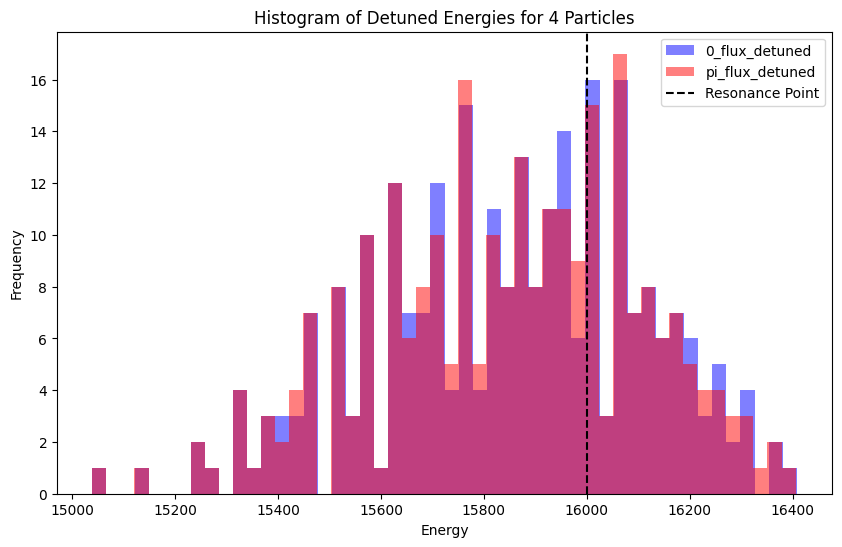

In [41]:
### plot detuned energies as histograms for 4 particles

### note that they should be exactly the negatives of each other

plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_detuned', 'pi_flux_detuned'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Detuned Energies for 4 Particles')
plt.legend()
plt.show()

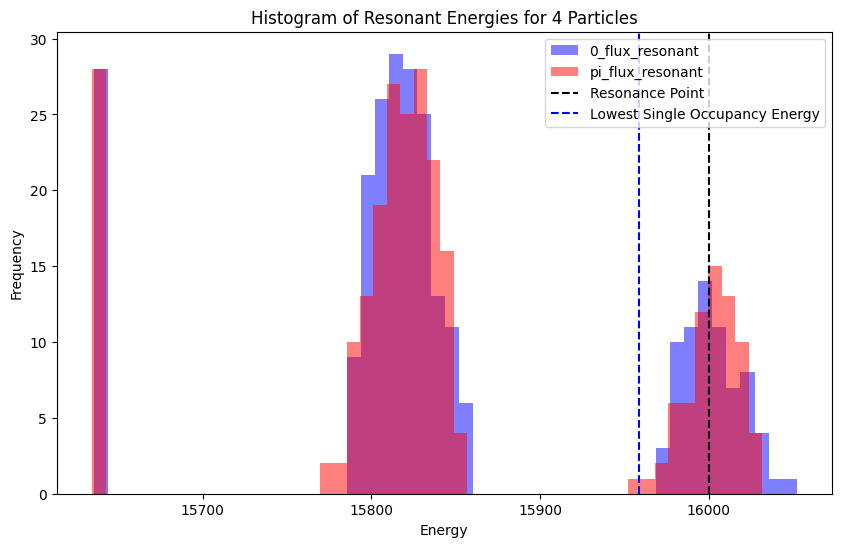

In [48]:
### plot the resonant energies as histograms for 4 particles
plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_resonant', 'pi_flux_resonant'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

lowest_single_occupancy_energy = label_to_particle_number_eigenenergy_dict[label][num_particles][-70]/2/np.pi
plt.axvline(lowest_single_occupancy_energy, color='blue', linestyle='--', label='Lowest Single Occupancy Energy')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Resonant Energies for 4 Particles')
plt.legend()
plt.show()

In [49]:
### calcultae current correlations with current operators

current_operators = []
for i in range(len(annihilation_operators)-1):
    a_i = annihilation_operators[i]
    a_j = annihilation_operators[i + 1]
    j_ij = 1j * J * (a_i.dag() * a_j - a_j.dag() * a_i)
    current_operators.append(j_ij)

# assume 1234
current_correlator = current_operators[0] * current_operators[2]

for labels in ['0_flux_resonant', 'pi_flux_resonant']:
    eigenstates = label_to_particle_number_eigenstate_dict[labels][num_particles]


    highest = eigenstates[-1]
    lowest = eigenstates[-70]


    currents_highest = [qt.expect(current_operators[i], highest) for i in range(len(current_operators))]
    currents_lowest = [qt.expect(current_operators[i], lowest) for i in range(len(current_operators))]

    correlation_highest = qt.expect(current_correlator, highest) - currents_highest[0] * currents_highest[2]
    correlation_lowest = qt.expect(current_correlator, lowest) - currents_lowest[0] * currents_lowest[2]

    print(f'Current correlations for {labels} Hamiltonian:')
    print(f'Highest energy state: {np.round(correlation_highest/J/J, 6)}')
    print(f'Lowest energy state: {np.round(correlation_lowest/J/J, 6)}')
    print()

Current correlations for 0_flux_resonant Hamiltonian:
Highest energy state: 0.062955
Lowest energy state: 0.313907

Current correlations for pi_flux_resonant Hamiltonian:
Highest energy state: 0.322089
Lowest energy state: 0.068418



In [68]:
### calculate corrent correlations with fock state representation
basis = list(product(range(num_levels), repeat=num_qubits))

lowest_pi_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][-70])
highest_pi_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][-1])

lowest_0_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['0_flux_resonant'][num_particles][-70])
highest_0_fock = convert_reduced_to_fock_state(basis, label_to_particle_number_eigenstate_dict['0_flux_resonant'][num_particles][-1])


print(get_current_correlation(lowest_pi_fock, J, J, 1, 2, 3, 4))
print(get_current_correlation(highest_pi_fock, J, J, 1, 2, 3, 4))

print(get_current_correlation(lowest_0_fock, J, J, 1, 2, 3, 4))
print(get_current_correlation(highest_0_fock, J, J, 1, 2, 3, 4))


0.06841788632537806
0.32208946215267487
0.313906699407724
0.0629554002580379


### 2.2 Testing

266


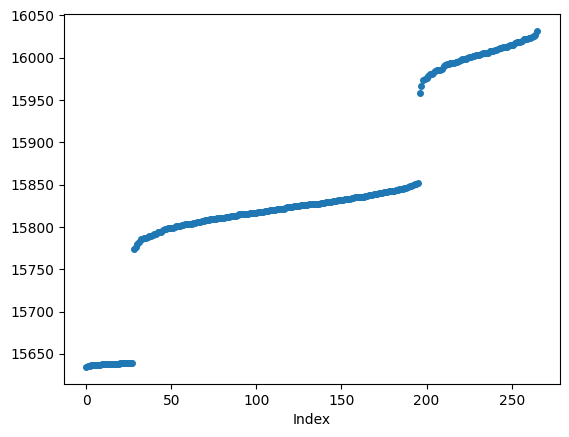

In [51]:
H_det_pi_3_levels = label_to_Hamiltonian['pi_flux_detuned']
H_res_pi_3_levels = label_to_Hamiltonian['pi_flux_resonant']

energies = label_to_particle_number_eigenenergy_dict['pi_flux_resonant'][num_particles]/2/np.pi

print(len(energies))

plt.plot(energies, 'o', markersize=4)
plt.xlabel('Index')
plt.show()

In [85]:
### check current correlations for resonant hamiltonians in 3-level basis with fock state representation

resonant_labels = ['0_flux_resonant', 'pi_flux_resonant']
for label in resonant_labels:
    print(f'Calculating expectations for label: {label}')
    eigenstates = label_to_particle_number_eigenstate_dict[label][num_particles]
    lowest = eigenstates[-70]
    highest = eigenstates[-1]

    if 'pi' in label:
        J_parallel = -abs(J)
    else:
        J_parallel = abs(J)

    highest_fock = convert_reduced_to_fock_state(basis, highest)
    lowest_fock = convert_reduced_to_fock_state(basis, lowest)

    currents_highest = get_current_expectations(highest_fock, J, J_parallel)
    currents_lowest = get_current_expectations(lowest_fock, J, J_parallel)

    current_correlations_highest = get_current_correlation(highest_fock, J, J_parallel, 1, 2, 3, 4) - currents_highest[0] * currents_highest[2]
    current_correlations_lowest = get_current_correlation(lowest_fock, J, J_parallel, 1, 2, 3, 4) - currents_lowest[0] * currents_lowest[2]


    print(f'Current correlations for highest and lowest of {label} Hamiltonian:')
    print(f'{np.round(current_correlations_highest, 6)}')
    print(f'{np.round(current_correlations_lowest, 6)}')
    print()

Calculating expectations for label: 0_flux_resonant
Current correlations for highest and lowest of 0_flux_resonant Hamiltonian:
0.062955
0.313907

Calculating expectations for label: pi_flux_resonant
Current correlations for highest and lowest of pi_flux_resonant Hamiltonian:
0.322089
0.068418



In [99]:
### create submatrix of H for 4 particle, single or double occupation states only
basis = list(product(range(num_levels), repeat=num_qubits))
basis_3_levels = [state for state in basis if sum(state) == num_particles and np.all(np.array(state) <= 2)]

H = H_res_pi_3_levels
 
full_to_reduced_index_map = {}
reduced_to_full_index_map = {}
for i in range(len(basis)):
    if sum(basis[i]) == num_particles and np.all(np.array(basis[i]) <= 2):
        reduced_index = len(full_to_reduced_index_map)
        full_to_reduced_index_map[i] = reduced_index
        reduced_to_full_index_map[reduced_index] = i

# H_reduced_3_levels = np.zeros((len(basis_3_levels), len(basis_3_levels)), dtype=complex)
# for i in range(len(basis_3_levels)):
#     full_index_1 = reduced_to_full_index_map[i]
#     for j in range(len(basis_3_levels)):
#         print(j)
#         full_index_2 = reduced_to_full_index_map[j]
#         H_reduced_3_levels[i, j] = H[full_index_1, full_index_2]


# Build the list of full indices in the correct order
reduced_full_indices = np.array([reduced_to_full_index_map[i] for i in range(len(basis_3_levels))])

# Extract reduced matrix in one shot
H_reduced_3_levels = H[np.ix_(reduced_full_indices, reduced_full_indices)]





In [114]:
### diagonalize H_reduced_3_levels and compare to eigenvalues from full H

eigenvalues_reduced, eigenstates_reduced = np.linalg.eigh(H_reduced_3_levels)
eigenstates_reduced = eigenstates_reduced.T

eigenstate_lowest_reduced = eigenstates_reduced[-70]
eigenstate_highest_reduced = eigenstates_reduced[-1]

eigenvalues_full = label_to_particle_number_eigenenergy_dict['pi_flux_resonant'][num_particles]
eigenstate_lowest = label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][-70]
eigenstate_highest = label_to_particle_number_eigenstate_dict['pi_flux_resonant'][num_particles][-1]




# compare lowest and highest eigenstates
basis_reduced = [state for state in basis_3_levels if sum(state) == num_particles]

precision = 3
print(f'\t\t\t\t lowest_r\t lowest\t highest_r \t highest')
for i in range(len(basis_reduced)):
    state = basis_reduced[i]
    reduced_index = i
    full_index = reduced_to_full_index_map[reduced_index]
    print(f'{state}:\t {str(round(eigenstates_reduced[-70][reduced_index].real, precision))}\t\t' +
          str(round(eigenstate_lowest[full_index][0].real, precision)) +
          str(f'\t {str(round(eigenstates_reduced[-1][reduced_index].real, precision))}\t\t' +
          str(round(eigenstate_highest[full_index][0].real, precision))))

				 lowest_r	 lowest	 highest_r 	 highest
(0, 0, 0, 0, 0, 0, 2, 2):	 -0.0		0.0	 0.0		0.0
(0, 0, 0, 0, 0, 1, 1, 2):	 0.0		-0.0	 0.0		0.0
(0, 0, 0, 0, 0, 1, 2, 1):	 0.001		-0.001	 0.0		0.0
(0, 0, 0, 0, 0, 2, 0, 2):	 -0.0		0.0	 -0.0		-0.0
(0, 0, 0, 0, 0, 2, 1, 1):	 -0.003		0.003	 -0.002		-0.002
(0, 0, 0, 0, 0, 2, 2, 0):	 -0.0		0.0	 -0.0		-0.0
(0, 0, 0, 0, 1, 0, 1, 2):	 0.001		-0.001	 0.0		0.0
(0, 0, 0, 0, 1, 0, 2, 1):	 0.0		-0.0	 -0.0		-0.0
(0, 0, 0, 0, 1, 1, 0, 2):	 -0.0		0.0	 -0.0		-0.0
(0, 0, 0, 0, 1, 1, 1, 1):	 -0.016		0.016	 -0.004		-0.004
(0, 0, 0, 0, 1, 1, 2, 0):	 0.0		-0.0	 0.0		0.0
(0, 0, 0, 0, 1, 2, 0, 1):	 -0.003		0.003	 0.003		0.003
(0, 0, 0, 0, 1, 2, 1, 0):	 0.003		-0.003	 0.004		0.004
(0, 0, 0, 0, 2, 0, 0, 2):	 -0.001		0.001	 0.0		0.0
(0, 0, 0, 0, 2, 0, 1, 1):	 -0.009		0.009	 0.003		0.003
(0, 0, 0, 0, 2, 0, 2, 0):	 -0.001		0.001	 -0.0		-0.0
(0, 0, 0, 0, 2, 1, 0, 1):	 0.009		-0.009	 -0.001		-0.001
(0, 0, 0, 0, 2, 1, 1, 0):	 -0.007		0.007	 -0.004		-0.004
(0, 0, 0, 0, 2, 2, 0,

In [115]:
highest_fock = convert_reduced_to_fock_state(basis, qt.Qobj(eigenstate_highest))
lowest_fock = convert_reduced_to_fock_state(basis, qt.Qobj(eigenstate_lowest))

currents_highest = get_current_expectations(highest_fock, J, J_parallel)
currents_lowest = get_current_expectations(lowest_fock, J, J_parallel)

current_correlations_highest = get_current_correlation(highest_fock, J, J_parallel, 1, 2, 3, 4) - currents_highest[0] * currents_highest[2]
current_correlations_lowest = get_current_correlation(lowest_fock, J, J_parallel, 1, 2, 3, 4) - currents_lowest[0] * currents_lowest[2]

print(f'{np.round(current_correlations_highest, 6)}')
print(f'{np.round(current_correlations_lowest, 6)}')

0.322089
0.068418


In [117]:
highest_fock_reduced = convert_reduced_to_fock_state(basis_reduced, qt.Qobj(eigenstate_highest_reduced))
lowest_fock_reduced = convert_reduced_to_fock_state(basis_reduced, qt.Qobj(eigenstate_lowest_reduced))

currents_highest = get_current_expectations(highest_fock_reduced, J, J_parallel)
currents_lowest = get_current_expectations(lowest_fock_reduced, J, J_parallel)

current_correlations_highest = get_current_correlation(highest_fock_reduced, J, J_parallel, 1, 2, 3, 4) - currents_highest[0] * currents_highest[2]
current_correlations_lowest = get_current_correlation(lowest_fock_reduced, J, J_parallel, 1, 2, 3, 4) - currents_lowest[0] * currents_lowest[2]


print(f'{np.round(current_correlations_highest, 6)}')
print(f'{np.round(current_correlations_lowest, 6)}')

0.322089
0.068418


# 3. Interactions, 5 levels
Include many levels

### 3.1 Initial detuned and resonant Hamiltonians for 0 and $\pi$ flux

In [119]:
num_levels = 5
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz
J = abs(J)

U = -180* 2 * np.pi  # in MHz

times = np.linspace(0, 0.15, 21)  # us

resonance_point = 4e3 * 2 * np.pi  # in MHz
detunings = np.linspace(-175, 175, num_qubits) * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

simulation_detuned_0 = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J, U, times, [1,2],[3,4], initial_detunings=frequencies)
simulation_resonant_0 = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)

simulation_detuned_pi = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -J, U, times, [1,2],[3,4], initial_detunings=frequencies)
simulation_resonant_pi = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -J, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)

label_to_simulation = {
    '0_flux_detuned': simulation_detuned_0,
    '0_flux_resonant': simulation_resonant_0,
    'pi_flux_detuned': simulation_detuned_pi,
    'pi_flux_resonant': simulation_resonant_pi
}

label_to_Hamiltonian = {
    '0_flux_detuned': simulation_detuned_0.initial_Hamiltonian,
    '0_flux_resonant': simulation_resonant_0.initial_Hamiltonian,
    'pi_flux_detuned': simulation_detuned_pi.initial_Hamiltonian,
    'pi_flux_resonant': simulation_resonant_pi.initial_Hamiltonian
}

[3825. 3875. 3925. 3975. 4025. 4075. 4125. 4175.]
[24033.18379996 24347.34306532 24661.50233068 24975.66159604
 25289.8208614  25603.98012676 25918.13939212 26232.29865747]
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
[4000. 4000. 4000. 4000. 4000. 4000. 4000. 4000.]
[25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343]
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
[  0.  50. 100. 150. 200. 250. 300. 350.]
[   0.          314.15926536  628.31853072  942.47779608 1256.63706144
 1570.79632679 1884.95559215 2199.11485751]
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
[4000. 4000. 4000. 4000. 4000. 4000. 4000. 4000.]
[25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343, 25132.741228718343]
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>


In [120]:
basis = list(product(range(num_levels), repeat=num_qubits))
basis_4_particles = [state for state in basis if sum(state) == num_particles]

H = label_to_Hamiltonian['pi_flux_detuned']
H = label_to_Hamiltonian['pi_flux_resonant']

for i in range(len(basis_4_particles)):
    state = basis_4_particles[i]
    if np.any(np.array(state) > 1):
        continue
    print(f'{state}: {round(H[i,i].real/2/np.pi)}')

(0, 0, 0, 0, 1, 1, 1, 1): 16000
(0, 0, 0, 1, 0, 1, 1, 1): 16000
(0, 0, 0, 1, 1, 0, 1, 1): 16000
(0, 0, 0, 1, 1, 1, 0, 1): 16000
(0, 0, 0, 1, 1, 1, 1, 0): 16000
(0, 0, 1, 0, 0, 1, 1, 1): 16000
(0, 0, 1, 0, 1, 0, 1, 1): 16000
(0, 0, 1, 0, 1, 1, 0, 1): 16000
(0, 0, 1, 0, 1, 1, 1, 0): 16000
(0, 0, 1, 1, 0, 0, 1, 1): 16000
(0, 0, 1, 1, 0, 1, 0, 1): 16000
(0, 0, 1, 1, 0, 1, 1, 0): 16000
(0, 0, 1, 1, 1, 0, 0, 1): 16000
(0, 0, 1, 1, 1, 0, 1, 0): 16000
(0, 0, 1, 1, 1, 1, 0, 0): 16000
(0, 1, 0, 0, 0, 1, 1, 1): 16000
(0, 1, 0, 0, 1, 0, 1, 1): 16000
(0, 1, 0, 0, 1, 1, 0, 1): 16000
(0, 1, 0, 0, 1, 1, 1, 0): 16000
(0, 1, 0, 1, 0, 0, 1, 1): 16000
(0, 1, 0, 1, 0, 1, 0, 1): 16000
(0, 1, 0, 1, 0, 1, 1, 0): 16000
(0, 1, 0, 1, 1, 0, 0, 1): 16000
(0, 1, 0, 1, 1, 0, 1, 0): 16000
(0, 1, 0, 1, 1, 1, 0, 0): 16000
(0, 1, 1, 0, 0, 0, 1, 1): 16000
(0, 1, 1, 0, 0, 1, 0, 1): 16000
(0, 1, 1, 0, 0, 1, 1, 0): 16000
(0, 1, 1, 0, 1, 0, 0, 1): 16000
(0, 1, 1, 0, 1, 0, 1, 0): 16000
(0, 1, 1, 0, 1, 1, 0, 0): 16000
(0, 1, 1

In [121]:
label_to_particle_number_eigenenergy_dict = {}
label_to_particle_number_eigenstate_dict = {}

for label in label_to_simulation:
    
    label_to_particle_number_eigenenergy_dict[label] = label_to_simulation[label].particle_number_to_eigenenergy.copy()
    label_to_particle_number_eigenstate_dict[label] = label_to_simulation[label].particle_number_to_eigenstate.copy()

    # add resonance point energy to each qubit, since the current simulation class zeros it
    # also offset by the lowest detuning since this is also zeroed
    for number in label_to_particle_number_eigenenergy_dict[label]:
        energies = np.array(label_to_particle_number_eigenenergy_dict[label][number])
        offset = 0
        # offset = resonance_point * num_qubits/2
        # offset = resonance_point * num_qubits/2 + min(detunings) * num_qubits/2
        label_to_particle_number_eigenenergy_dict[label][number] = energies + offset

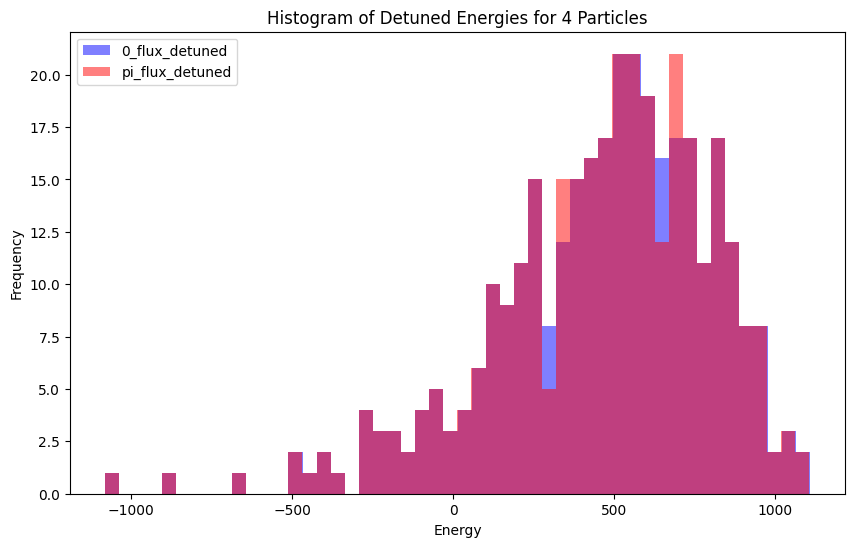

In [122]:
### plot detuned energies as histograms for 4 particles

### note that they should be exactly the negatives of each other

plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_detuned', 'pi_flux_detuned'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

# plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Detuned Energies for 4 Particles')
plt.legend()
plt.show()

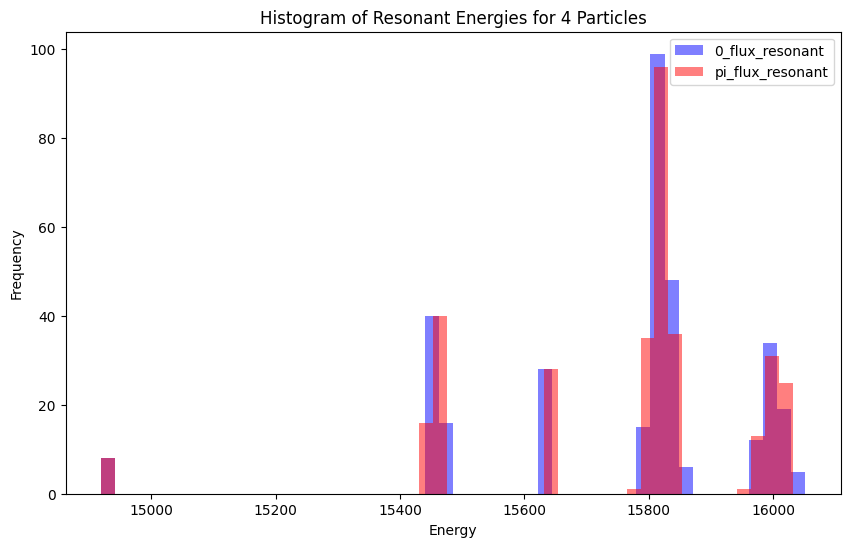

In [123]:
### plot the resonant energies as histograms for 4 particles
plt.figure(figsize=(10, 6))
for label, color in zip(['0_flux_resonant', 'pi_flux_resonant'], ['blue', 'red']):
    energies = label_to_particle_number_eigenenergy_dict[label][num_particles]/2/np.pi
    plt.hist(energies, bins=50, alpha=0.5, label=label, color=color)

# plt.axvline(resonance_point*num_particles/2/np.pi, color='black', linestyle='--', label='Resonance Point')


plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Resonant Energies for 4 Particles')
plt.legend()
plt.show()

### 2.2 Calculate Current Correlations

Using fock state representation

In [124]:
### find the index of the lowest single occupancy state

# find number of states with multiple occupancy

count = 0
for i in range(len(basis_4_particles)):
    state = basis_4_particles[i]
    if np.any(np.array(state) > 1):
        count += 1

print(count)
lowest_state_index = count

260


In [10]:
### try measuring current with fock state representation

# calculate correlations
# current operator is -J_ij(a_i^dagger a_j - a_j^dagger a_i)*J_kl(a_k^dagger a_l - a_l^dagger a_k)


# print('calculating current correlations with initial state:')
# print(psi0)

def get_current_expectations(psi0_fock, J, J_parallel):
    # define the leg current operator as j_j,m = −iJ(exp(iχ(−1)^m b†_j,m b_j+1,m − H.c.)
    # let's define the phase through each plaquette as chi. Let's put all the phase in the J_parallel coupling, so rung coupling is the same but with chi = 0
    # for example, for a right side up plaquette, j_j,1 = −iJ(exp(-iχ b†_j,1 b_j+1,1 − H.c.)
    # for example, for a upside down plaquette, j_j,2 = −iJ(exp(iχ b†_j,2 b_j+1,2 − H.c.)
    # phase information stored in coupling in Hamiltonian matrix element

    current_expectations = []
    for i in range(num_qubits - 1):
            
        q_1 = i + 1
        q_2 = i + 2


        if abs(q_1 - q_2) == 1:
            coupling = J
        elif abs(q_1 - q_2) == 2:
            coupling = J_parallel
        else:
            coupling = 0


        value = 0
        # a_i^dagger a_j term
        new_state = psi0_fock.apply_raising_operator(q_1-1, num_levels).apply_lowering_operator(q_2-1)
        value += psi0_fock.inner_product(new_state) * -1j * coupling
        # a_j^dagger a_i term
        new_state = psi0_fock.apply_lowering_operator(q_1-1).apply_raising_operator(q_2-1, num_levels)
        value -= psi0_fock.inner_product(new_state) * -1j * np.conjugate(coupling)

        # for rung currents starting at top rung, (odd qubits) multiply by -1
        if abs(q_1 - q_2) == 1 and q_1 % 2 == 1:
            value *= -1

        current_expectations.append(value.real/J)
        
    return current_expectations

def get_current_correlation(psi0_fock, J, J_parallel, q_11, q_12, q_21, q_22):



    # define the leg current operator as j_j,m = −iJ(exp(iχ(−1)^m b†_j,m b_j+1,m − H.c.)
    # let's define the phase through each plaquette as chi. Let's put all the phase in the J_parallel coupling, so rung coupling is the same but with chi = 0
    # for example, for a right side up plaquette, j_j,1 = −iJ(exp(-iχ b†_j,1 b_j+1,1 − H.c.)
    # for example, for a upside down plaquette, j_j,2 = −iJ(exp(iχ b†_j,2 b_j+1,2 − H.c.)
    # phase information stored in coupling in Hamiltonian matrix element




    if abs(q_11 - q_12) == 1:
        coupling_1 = J
    elif abs(q_11 - q_12) == 2:
        coupling_1 = J_parallel
    else:
        coupling_1 = 0

    if abs(q_21 - q_22) == 1:
        coupling_2 = J
    elif abs(q_21 - q_22) == 2:
        coupling_2 = J_parallel
    else:
        coupling_2 = 0

    value = 0
    # a_i^dagger a_j a_k^dagger a_l
    new_state = psi0_fock.apply_raising_operator(q_11-1, num_levels).apply_lowering_operator(q_12-1).apply_raising_operator(q_21-1, num_levels).apply_lowering_operator(q_22-1)
    value -= psi0_fock.inner_product(new_state) * coupling_1 * coupling_2

    # a_i^dagger a_j a_l^dagger a_k
    new_state = psi0_fock.apply_raising_operator(q_11-1, num_levels).apply_lowering_operator(q_12-1).apply_raising_operator(q_22-1, num_levels).apply_lowering_operator(q_21-1)
    value += psi0_fock.inner_product(new_state) * coupling_1 * np.conjugate(coupling_2)

    # a_j^dagger a_i a_k^dagger a_l
    new_state = psi0_fock.apply_raising_operator(q_12-1, num_levels).apply_lowering_operator(q_11-1).apply_raising_operator(q_21-1, num_levels).apply_lowering_operator(q_22-1)
    value += psi0_fock.inner_product(new_state) * np.conjugate(coupling_1) * coupling_2

    # a_j^dagger a_i a_l^dagger a_k
    new_state = psi0_fock.apply_raising_operator(q_12-1, num_levels).apply_lowering_operator(q_11-1).apply_raising_operator(q_22-1, num_levels).apply_lowering_operator(q_21-1)
    value -= psi0_fock.inner_product(new_state) * np.conjugate(coupling_1) * np.conjugate(coupling_2)

    # for rung currents starting at top rung, (odd qubits) multiply by -1
    if abs(q_11 - q_12) == 1 and q_11 % 2 == 1:
        value *= -1
    if abs(q_21 - q_22) == 1 and q_21 % 2 == 1:
        value *= -1

    return value.real/J/J

def get_number_expectations(psi0_fock):

    number_expectations = []
    for i in range(num_qubits):
        q = i + 1
        # n_q = a_q^dagger a_q
        new_state = psi0_fock.apply_lowering_operator(q-1).apply_raising_operator(q-1, num_levels)
        value = psi0_fock.inner_product(new_state)
        number_expectations.append(value.real)
    return number_expectations


def expectations_for_state_fock(psi0, J, J_parallel):
        
    all_qubits = list(range(1, num_qubits+1))
    all_qubit_pairs = list(combinations(all_qubits, 2))

    psi0_fock = convert_reduced_to_fock_state(basis_4_particles, psi0)
    

    current_correlations = get_current_correlation(psi0_fock, J, J_parallel, 1,2,3,4)

    number_expectations = get_number_expectations(psi0_fock)

    current_expectations = get_current_expectations(psi0_fock, J, J_parallel)

    current_correlations_connected = current_correlations - current_expectations[1]*current_expectations[3]
    
    return dict(n_expect=number_expectations, j_expect=current_expectations, jj_corr=current_correlations, jj_conn=current_correlations_connected)



In [127]:
resonant_labels = ['0_flux_resonant', 'pi_flux_resonant']
for label in resonant_labels:
    print(f'Calculating expectations for label: {label}')
    eigenstates = label_to_particle_number_eigenstate_dict[label][num_particles]
    lowest = eigenstates[-70]
    highest = eigenstates[-1]

    if 'pi' in label:
        J_parallel = -abs(J)
    else:
        J_parallel = abs(J)

    expectations_lowest = expectations_for_state_fock(lowest, J, J_parallel)
    expectations_highest = expectations_for_state_fock(highest, J, J_parallel)

    # print(f'Lowest state: n_expect = {expectations_lowest["n_expect"]}, j_expect = {expectations_lowest["j_expect"]}, jj_corr = {expectations_lowest["jj_corr"]}, jj_conn = {expectations_lowest["jj_conn"]}')
    # print(f'Highest state: n_expect = {expectations_highest["n_expect"]}, j_expect = {expectations_highest["j_expect"]}, jj_corr = {expectations_highest["jj_corr"]}, jj_conn = {expectations_highest["jj_conn"]}')

    print(f'highest state: {expectations_highest["jj_conn"]}')
    print(f'lowest state: {expectations_lowest["jj_conn"]}')

    # print(f'highest state: {expectations_highest["j_expect"]}')
    # print(f'lowest state: {expectations_lowest["j_expect"]}')

    print()

Calculating expectations for label: 0_flux_resonant
highest state: 0.06420877801807202
lowest state: 0.313923352411054

Calculating expectations for label: pi_flux_resonant
highest state: 0.3222188869392485
lowest state: 0.0704170568418926



In [128]:
### print matrix elements of (1,1,1,1,0,0,0,0) state for pi flux resonant


H = label_to_Hamiltonian['pi_flux_resonant']

index = -1
for i in range(len(basis_4_particles)):
    if basis_4_particles[i] == (1,1,1,1,0,0,0,0):
        index = i
        break

for i in range(len(basis_4_particles)):
    state = basis_4_particles[i]
    matrix_element = H[index,i]
    if abs(matrix_element) > 1e-6 and np.all(np.array(state) <= 1):
        print(f'{basis_4_particles[index]} to {state}: {matrix_element/2/np.pi}')

(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 0, 1, 1, 0, 0, 0): (-6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 0, 0, 1, 0, 0): (-6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 0, 1, 0, 0, 0): (6+0j)
(1, 1, 1, 1, 0, 0, 0, 0) to (1, 1, 1, 1, 0, 0, 0, 0): (16000+0j)


# 4. Sweep U/J

In [11]:
num_levels = 5
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz
J = abs(J)

U = -180* 2 * np.pi  # in MHz

times = np.linspace(0, 0.15, 21)  # us

resonance_point = 4e3 * 2 * np.pi  # in MHz
detunings = np.linspace(-175, 175, num_qubits) * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4_particles = [state for state in basis if sum(state) == num_particles]



In [23]:
# define J/U ratios
ratios = np.logspace(-3, 0, 100)


lowest_energies_0 = np.zeros(ratios.shape)
lowest_energies_pi = np.zeros(ratios.shape)

highest_energies_0 = np.zeros(ratios.shape)
highest_energies_pi = np.zeros(ratios.shape)

current_correlations_lowest_0 = np.zeros(ratios.shape)
current_correlations_lowest_pi = np.zeros(ratios.shape)
current_correlations_highest_0 = np.zeros(ratios.shape)
current_correlations_highest_pi = np.zeros(ratios.shape)

for i in range(len(ratios)):

    ratio = ratios[i]
    U = -abs(J/ratio)
    print(f'J/U: {ratio}, J: {J/2/np.pi} MHz, U: {U/2/np.pi} MHz')

    simulation_0 = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)
    simulation_pi = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -J, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)

    particle_number_to_eigenenergy_0 = simulation_0.particle_number_to_eigenenergy
    particle_number_to_eigenenergy_pi = simulation_pi.particle_number_to_eigenenergy

    particle_number_to_eigenstate_0 = simulation_0.particle_number_to_eigenstate
    particle_number_to_eigenstate_pi = simulation_pi.particle_number_to_eigenstate

    lowest_energies_0[i] = particle_number_to_eigenenergy_0[num_particles][-70]/2/np.pi
    highest_energies_0[i] = particle_number_to_eigenenergy_0[num_particles][-1]/2/np.pi
    lowest_energies_pi[i] = particle_number_to_eigenenergy_pi[num_particles][-70]/2/np.pi
    highest_energies_pi[i] = particle_number_to_eigenenergy_pi[num_particles][-1]/2/np.pi

    lowest_0 = particle_number_to_eigenstate_0[num_particles][-70]
    highest_0 = particle_number_to_eigenstate_0[num_particles][-1]

    lowest_pi = particle_number_to_eigenstate_pi[num_particles][-70]
    highest_pi = particle_number_to_eigenstate_pi[num_particles][-1]


    expectations_lowest_0 = expectations_for_state_fock(lowest_0, J, J)
    expectations_highest_0 = expectations_for_state_fock(highest_0, J, J)

    expectations_lowest_pi = expectations_for_state_fock(lowest_pi, J, -J)
    expectations_highest_pi = expectations_for_state_fock(highest_pi, J, -J)

    current_correlations_lowest_0[i] = expectations_lowest_0['jj_conn']
    current_correlations_highest_0[i] = expectations_highest_0['jj_conn']
    current_correlations_lowest_pi[i] = expectations_lowest_pi['jj_conn']
    current_correlations_highest_pi[i] = expectations_highest_pi['jj_conn']

J/U: 0.001, J: 6.0 MHz, U: -6000.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J/U: 0.0010722672220103231, J: 6.0 MHz, U: -5595.620081299319 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J/U: 0.0011497569953977356, J: 6.0 MHz, U: -5218.4940157067 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J/U: 0.0012328467394420659, J: 6.0 MHz, U: -4866.784984738124 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J/U: 0.0013219411484660286, J: 6.0 MHz, U: -4538.779965327774 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J/U: 0.0014174741629268048, J: 6.0 MHz, U: -4232.881386431187 MHz
processing psi0, given type: <cla

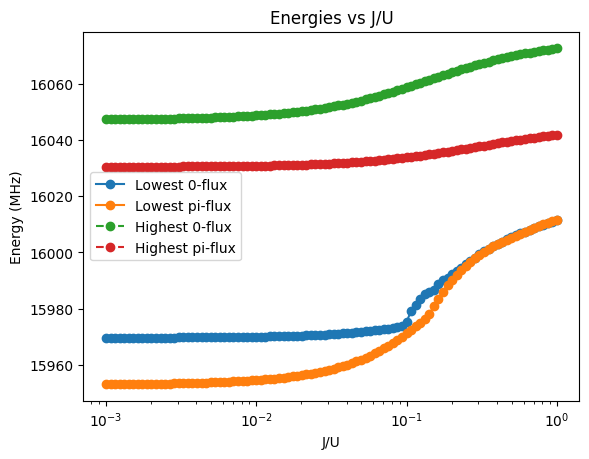

In [24]:
plt.plot(ratios, lowest_energies_0, 'o-', label='Lowest 0-flux')
plt.plot(ratios, lowest_energies_pi, 'o-', label='Lowest pi-flux')
plt.plot(ratios, highest_energies_0, 'o--', label='Highest 0-flux')
plt.plot(ratios, highest_energies_pi, 'o--', label='Highest pi-flux')

plt.xscale('log')
plt.xlabel('J/U')
plt.ylabel('Energy (MHz)')

plt.legend()
plt.title('Energies vs J/U')

plt.show()

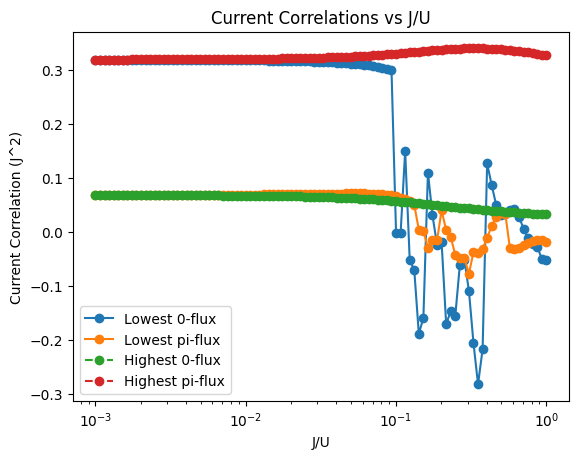

In [25]:
plt.plot(ratios, current_correlations_lowest_0, 'o-', label='Lowest 0-flux')
plt.plot(ratios, current_correlations_lowest_pi, 'o-', label='Lowest pi-flux')
plt.plot(ratios, current_correlations_highest_0, 'o--', label='Highest 0-flux')
plt.plot(ratios, current_correlations_highest_pi, 'o--', label='Highest pi-flux')
plt.xscale('log')
plt.xlabel('J/U')
plt.ylabel('Current Correlation (J^2)')
plt.legend()
plt.title('Current Correlations vs J/U')
plt.show()

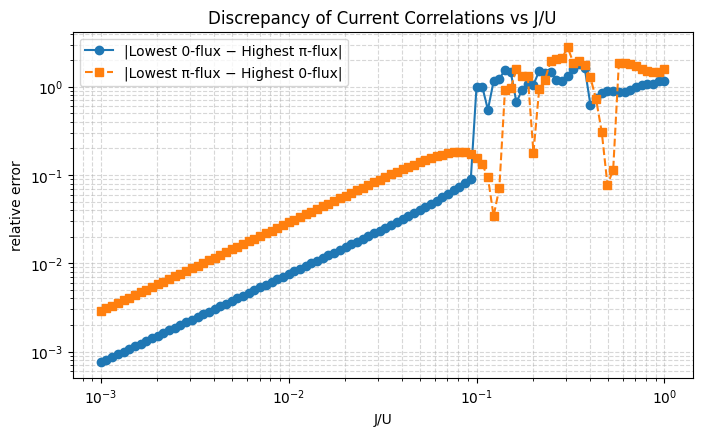

In [26]:
# plot discrepancies of current correlations on a log-log scale

delta_low0_highpi = np.abs((current_correlations_lowest_0 - current_correlations_highest_pi)/(current_correlations_highest_pi))
delta_lowpi_high0 = np.abs((current_correlations_lowest_pi - current_correlations_highest_0)/(current_correlations_highest_0))

# avoid zero values for log plotting
eps = 1e-16
y1 = np.maximum(delta_low0_highpi, eps)
y2 = np.maximum(delta_lowpi_high0, eps)

plt.figure(figsize=(8, 4.5))
plt.loglog(ratios, y1, 'o-', label='|Lowest 0-flux − Highest π-flux|')
plt.loglog(ratios, y2, 's--', label='|Lowest π-flux − Highest 0-flux|')
plt.xlabel('J/U')
plt.ylabel('relative error')
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Discrepancy of Current Correlations vs J/U')
plt.show()

# 5. Sweep $J_{||}$/$J$

In [27]:
num_levels = 5
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz
J = abs(J)

U = -180* 2 * np.pi  # in MHz

times = np.linspace(0, 0.15, 21)  # us

resonance_point = 4e3 * 2 * np.pi  # in MHz
detunings = np.linspace(-175, 175, num_qubits) * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4_particles = [state for state in basis if sum(state) == num_particles]




In [28]:
# define J_||/J ratios
ratios = np.linspace(0, 5, 101)
# ratios = np.linspace(0, 5, 101)


lowest_energies_0 = np.zeros(ratios.shape)
lowest_energies_pi = np.zeros(ratios.shape)

highest_energies_0 = np.zeros(ratios.shape)
highest_energies_pi = np.zeros(ratios.shape)

current_correlations_lowest_0 = np.zeros(ratios.shape)
current_correlations_lowest_pi = np.zeros(ratios.shape)
current_correlations_highest_0 = np.zeros(ratios.shape)
current_correlations_highest_pi = np.zeros(ratios.shape)

for i in range(len(ratios)):

    ratio = ratios[i]
    J_parallel = abs(J*ratio)
    print(f'J_||/J: {ratio}, J: {J/2/np.pi} MHz, J_||: {J_parallel/2/np.pi} MHz')

    simulation_0 = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)
    simulation_pi = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -J_parallel, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)

    particle_number_to_eigenenergy_0 = simulation_0.particle_number_to_eigenenergy
    particle_number_to_eigenenergy_pi = simulation_pi.particle_number_to_eigenenergy

    particle_number_to_eigenstate_0 = simulation_0.particle_number_to_eigenstate
    particle_number_to_eigenstate_pi = simulation_pi.particle_number_to_eigenstate

    lowest_energies_0[i] = particle_number_to_eigenenergy_0[num_particles][-70]/2/np.pi
    highest_energies_0[i] = particle_number_to_eigenenergy_0[num_particles][-1]/2/np.pi
    lowest_energies_pi[i] = particle_number_to_eigenenergy_pi[num_particles][-70]/2/np.pi
    highest_energies_pi[i] = particle_number_to_eigenenergy_pi[num_particles][-1]/2/np.pi

    lowest_0 = particle_number_to_eigenstate_0[num_particles][-70]
    highest_0 = particle_number_to_eigenstate_0[num_particles][-1]

    lowest_pi = particle_number_to_eigenstate_pi[num_particles][-70]
    highest_pi = particle_number_to_eigenstate_pi[num_particles][-1]


    expectations_lowest_0 = expectations_for_state_fock(lowest_0, J, J)
    expectations_highest_0 = expectations_for_state_fock(highest_0, J, J)

    expectations_lowest_pi = expectations_for_state_fock(lowest_pi, J, -J)
    expectations_highest_pi = expectations_for_state_fock(highest_pi, J, -J)

    current_correlations_lowest_0[i] = expectations_lowest_0['jj_conn']
    current_correlations_highest_0[i] = expectations_highest_0['jj_conn']
    current_correlations_lowest_pi[i] = expectations_lowest_pi['jj_conn']
    current_correlations_highest_pi[i] = expectations_highest_pi['jj_conn']

J_||/J: 0.0, J: 6.0 MHz, J_||: 0.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.05, J: 6.0 MHz, J_||: 0.3 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.1, J: 6.0 MHz, J_||: 0.6 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.15000000000000002, J: 6.0 MHz, J_||: 0.9000000000000001 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.2, J: 6.0 MHz, J_||: 1.2 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.25, J: 6.0 MHz, J_||: 1.5 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.300

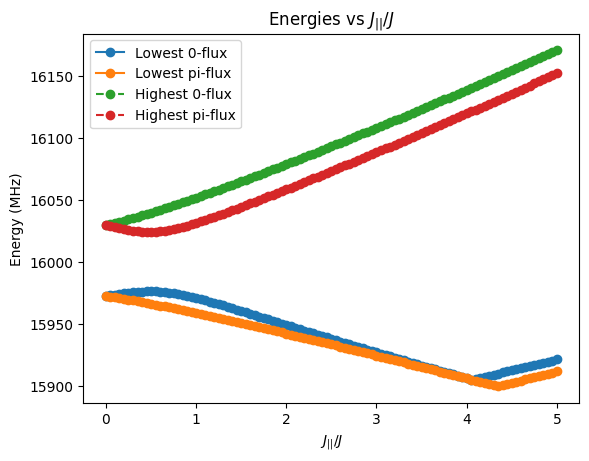

In [29]:

plt.plot(ratios, lowest_energies_0, 'o-', label='Lowest 0-flux')
plt.plot(ratios, lowest_energies_pi, 'o-', label='Lowest pi-flux')
plt.plot(ratios, highest_energies_0, 'o--', label='Highest 0-flux')
plt.plot(ratios, highest_energies_pi, 'o--', label='Highest pi-flux')

plt.xlabel('$J_{||}$/$J$')
plt.ylabel('Energy (MHz)')

plt.legend()
plt.title('Energies vs $J_{||}$/$J$')

plt.show()

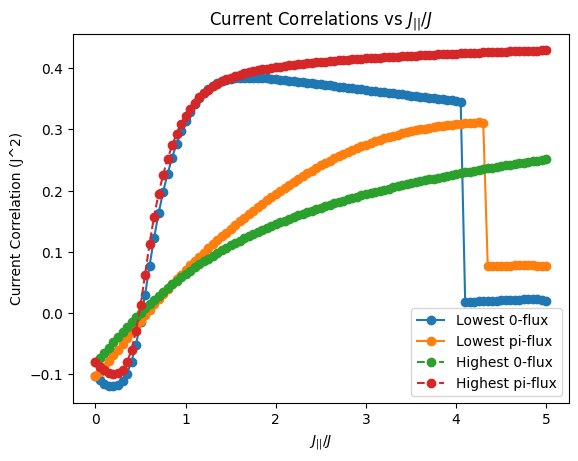

In [30]:
plt.plot(ratios, current_correlations_lowest_0, 'o-', label='Lowest 0-flux')
plt.plot(ratios, current_correlations_lowest_pi, 'o-', label='Lowest pi-flux')
plt.plot(ratios, current_correlations_highest_0, 'o--', label='Highest 0-flux')
plt.plot(ratios, current_correlations_highest_pi, 'o--', label='Highest pi-flux')

plt.xlabel('$J_{||}$/$J$')
plt.ylabel('Current Correlation (J^2)')

plt.legend()
plt.title('Current Correlations vs $J_{||}$/$J$')
plt.show()

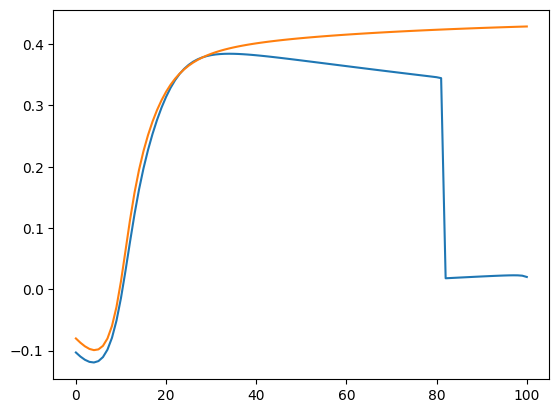

[]

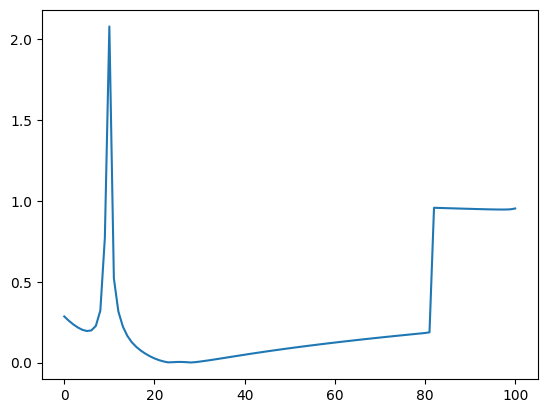

In [42]:
plt.plot(current_correlations_lowest_0)
plt.plot(current_correlations_highest_pi)
plt.show()

plt.plot(abs((current_correlations_lowest_0 - current_correlations_highest_pi)/current_correlations_highest_pi))
plt.plot()

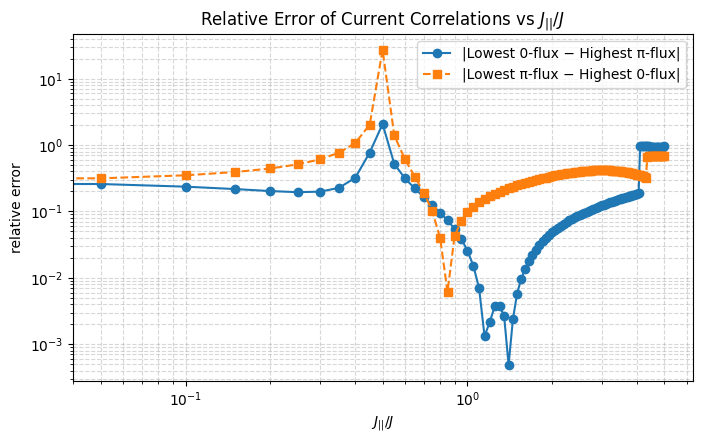

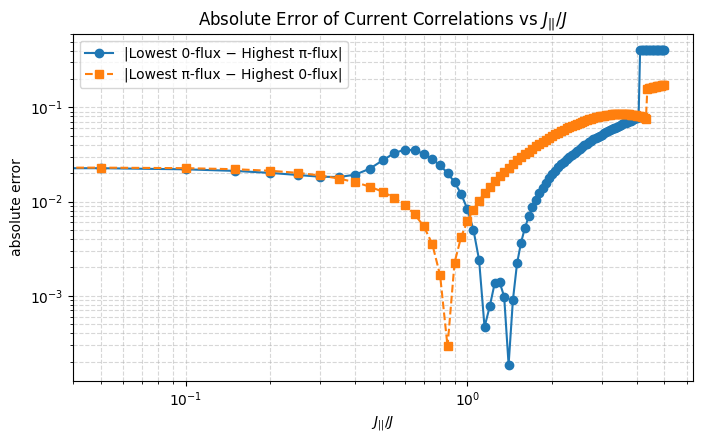

In [36]:
# plot discrepancies of current correlations on a log-log scale

delta_low0_highpi = np.abs((current_correlations_lowest_0 - current_correlations_highest_pi)/(current_correlations_highest_pi))
delta_lowpi_high0 = np.abs((current_correlations_lowest_pi - current_correlations_highest_0)/(current_correlations_highest_0))

# avoid zero values for log plotting
eps = 1e-16
y1 = np.maximum(delta_low0_highpi, eps)
y2 = np.maximum(delta_lowpi_high0, eps)

plt.figure(figsize=(8, 4.5))
plt.loglog(ratios, y1, 'o-', label='|Lowest 0-flux − Highest π-flux|')
plt.loglog(ratios, y2, 's--', label='|Lowest π-flux − Highest 0-flux|')
plt.xlabel('$J_{||}$/$J$')
plt.ylabel('relative error')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Relative Error of Current Correlations vs $J_{||}$/$J$')
plt.show()

# plot discrepancies of current correlations on a log-log scale

delta_low0_highpi = np.abs((current_correlations_lowest_0 - current_correlations_highest_pi))
delta_lowpi_high0 = np.abs((current_correlations_lowest_pi - current_correlations_highest_0))

# avoid zero values for log plotting
eps = 1e-16
y1 = np.maximum(delta_low0_highpi, eps)
y2 = np.maximum(delta_lowpi_high0, eps)

plt.figure(figsize=(8, 4.5))
plt.loglog(ratios, y1, 'o-', label='|Lowest 0-flux − Highest π-flux|')
plt.loglog(ratios, y2, 's--', label='|Lowest π-flux − Highest 0-flux|')
plt.xlabel('$J_{||}$/$J$')
plt.ylabel('absolute error')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Absolute Error of Current Correlations vs $J_{||}$/$J$')
plt.show()

# 6. Sweep $J_{||}$/$J$ and $U$/$J$.

In [43]:
num_levels = 5
num_qubits = 8
num_particles = 4

J = 6 * 2 * np.pi  # in MHz
J = abs(J)

U = -180* 2 * np.pi  # in MHz

times = np.linspace(0, 0.15, 21)  # us

resonance_point = 4e3 * 2 * np.pi  # in MHz

frequencies = resonance_point + detunings

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4_particles = [state for state in basis if sum(state) == num_particles]




In [44]:
J_ratios = np.linspace(0, 5, 21)
U_ratios = np.logspace(-3, 0, 21)

# J_ratios = np.linspace(0, 5, 6)
# U_ratios = np.logspace(-3, 0, 4)


lowest_energies_0_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
lowest_energies_pi_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
highest_energies_0_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
highest_energies_pi_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))

current_correlations_lowest_0_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
current_correlations_lowest_pi_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
current_correlations_highest_0_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))
current_correlations_highest_pi_2D = np.zeros((J_ratios.shape[0], U_ratios.shape[0]))



for i in range(len(J_ratios)):

    J_parallel = abs(J*J_ratios[i])

    for j in range(len(U_ratios)):
        U = -abs(J/U_ratios[j])
        print(f'J_||/J: {J_ratios[i]}, U/J: {U_ratios[j]} MHz, J: {J/2/np.pi} MHz')

        simulation_0 = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)
        simulation_pi = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -J_parallel, U, times, [1,2],[3,4], initial_detunings=[resonance_point]*num_qubits)

        particle_number_to_eigenenergy_0 = simulation_0.particle_number_to_eigenenergy
        particle_number_to_eigenenergy_pi = simulation_pi.particle_number_to_eigenenergy

        particle_number_to_eigenstate_0 = simulation_0.particle_number_to_eigenstate
        particle_number_to_eigenstate_pi = simulation_pi.particle_number_to_eigenstate

        lowest_energies_0_2D[i, j] = particle_number_to_eigenenergy_0[num_particles][-70]/2/np.pi
        highest_energies_0_2D[i, j] = particle_number_to_eigenenergy_0[num_particles][-1]/2/np.pi
        lowest_energies_pi_2D[i, j] = particle_number_to_eigenenergy_pi[num_particles][-70]/2/np.pi
        highest_energies_pi_2D[i, j] = particle_number_to_eigenenergy_pi[num_particles][-1]/2/np.pi

        lowest_0 = particle_number_to_eigenstate_0[num_particles][-70]
        highest_0 = particle_number_to_eigenstate_0[num_particles][-1]

        lowest_pi = particle_number_to_eigenstate_pi[num_particles][-70]
        highest_pi = particle_number_to_eigenstate_pi[num_particles][-1]


        expectations_lowest_0 = expectations_for_state_fock(lowest_0, J, J)
        expectations_highest_0 = expectations_for_state_fock(highest_0, J, J)

        expectations_lowest_pi = expectations_for_state_fock(lowest_pi, J, -J)
        expectations_highest_pi = expectations_for_state_fock(highest_pi, J, -J)

        current_correlations_lowest_0_2D[i, j] = expectations_lowest_0['jj_conn']
        current_correlations_highest_0_2D[i, j] = expectations_highest_0['jj_conn']
        current_correlations_lowest_pi_2D[i, j] = expectations_lowest_pi['jj_conn']
        current_correlations_highest_pi_2D[i, j] = expectations_highest_pi['jj_conn']

J_||/J: 0.0, U/J: 0.001 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.0, U/J: 0.001412537544622754 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.0, U/J: 0.001995262314968879 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.0, U/J: 0.002818382931264455 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.0, U/J: 0.003981071705534973 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
J_||/J: 0.0, U/J: 0.005623413251903491 MHz, J: 6.0 MHz
processing psi0, given type: <class 'qutip.core.qobj.Qobj'>
processing psi0, given ty

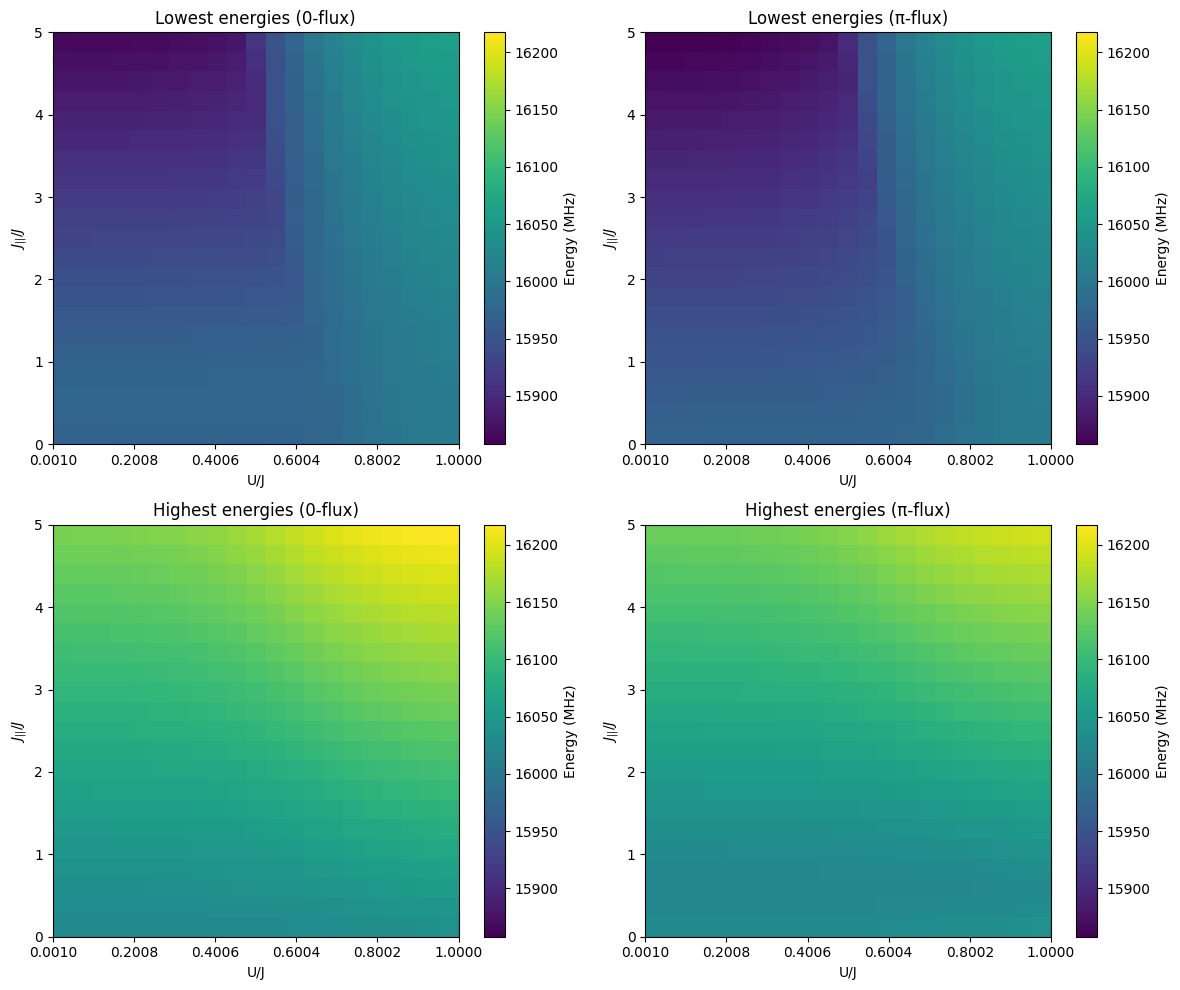

In [45]:
# 4-panel 2D color plots of energies vs U_ratio (x) and J_ratio (y)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

data_list = [lowest_energies_0_2D, lowest_energies_pi_2D, highest_energies_0_2D, highest_energies_pi_2D]
titles = ['Lowest energies (0-flux)', 'Lowest energies (π-flux)', 'Highest energies (0-flux)', 'Highest energies (π-flux)']

Jr = np.array(J_ratios)
Ur = np.array(U_ratios)

vmin = min(np.nanmin(d) for d in data_list)
vmax = max(np.nanmax(d) for d in data_list)

for ax, data, title in zip(axes.flat, data_list, titles):
    im = ax.imshow(np.array(data), origin='lower', aspect='auto',
                   extent=[Ur[0], Ur[-1], Jr[0], Jr[-1]],
                   vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('U/J')
    ax.set_ylabel('$J_{||}/J$')
    # show ticks at the actual ratio values for readability (optional)
    ax.set_xticks(np.linspace(Ur[0], Ur[-1], min(len(Ur), 6)))
    ax.set_yticks(np.linspace(Jr[0], Jr[-1], min(len(Jr), 6)))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Energy (MHz)')

plt.tight_layout()
plt.show()

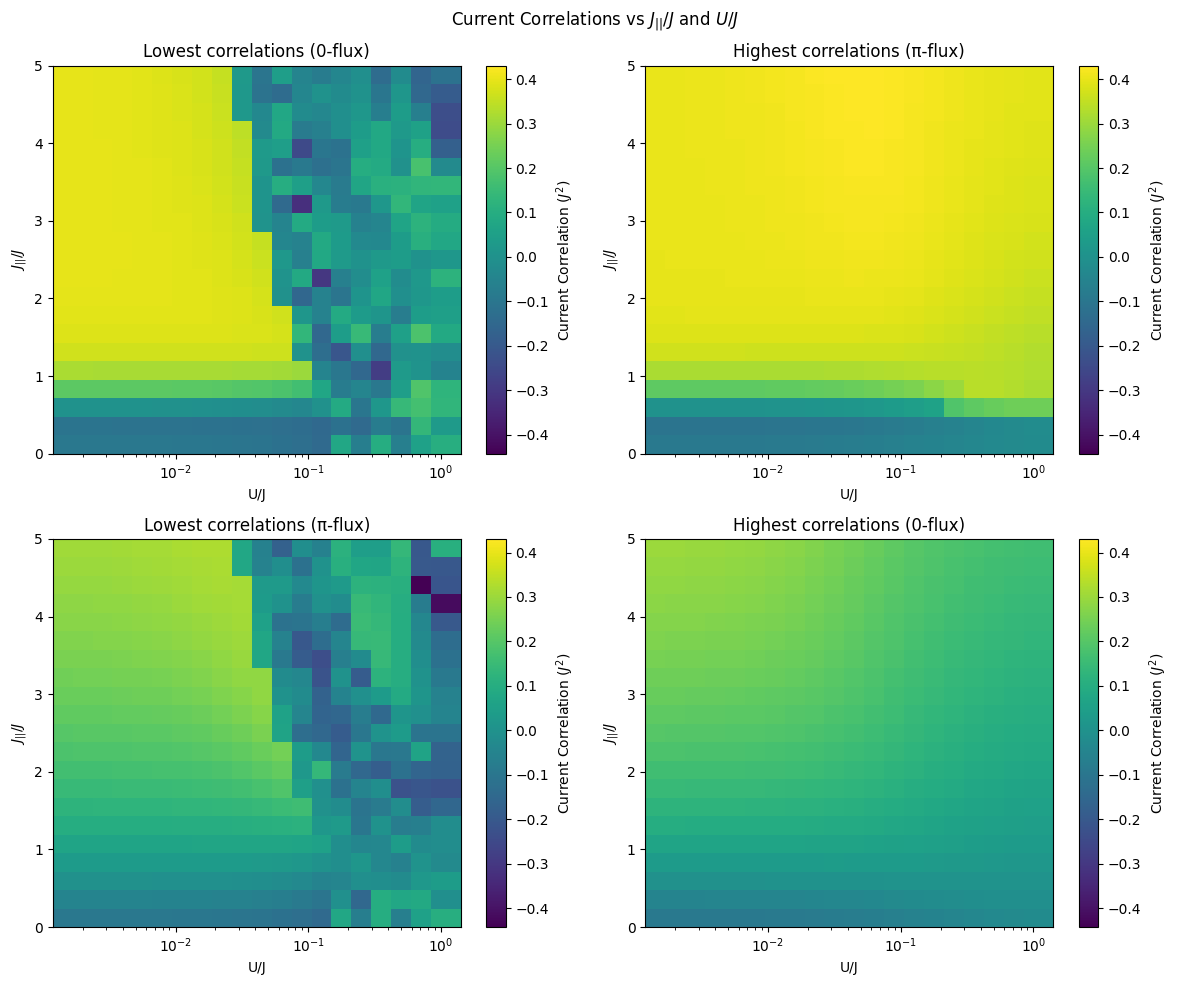

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

data_list = [
    current_correlations_lowest_0_2D,
    current_correlations_highest_pi_2D,
    current_correlations_lowest_pi_2D,
    current_correlations_highest_0_2D,
]
titles = [
    'Lowest correlations (0-flux)',
    'Highest correlations (π-flux)',
    'Lowest correlations (π-flux)',
    'Highest correlations (0-flux)',
]

Jr = np.array(J_ratios)
Ur = np.array(U_ratios)   # this is log-spaced

vmin = min(np.nanmin(d) for d in data_list)
vmax = max(np.nanmax(d) for d in data_list)

# Need grid edges for pcolormesh
# If Ur is length N, this will produce N+1 bin edges:
Ur_edges = np.concatenate(([Ur[0] * (Ur[1]/Ur[0])], (Ur[:-1] * Ur[1:] )**0.5, [Ur[-1] * (Ur[-1]/Ur[-2])]))
Jr_edges = np.linspace(Jr[0], Jr[-1], len(Jr) + 1)

for ax, data, title in zip(axes.flat, data_list, titles):
    pcm = ax.pcolormesh(Ur_edges, Jr_edges, data,
                         shading='auto', cmap='viridis',
                         vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('U/J')
    ax.set_ylabel('$J_{||}/J$')

    # HERE IS THE KEY LINE:
    ax.set_xscale('log')

    fig.colorbar(pcm, ax=ax).set_label('Current Correlation ($J^2$)')

plt.suptitle('Current Correlations vs $J_{||}/J$ and $U/J$')
plt.tight_layout()
plt.show()


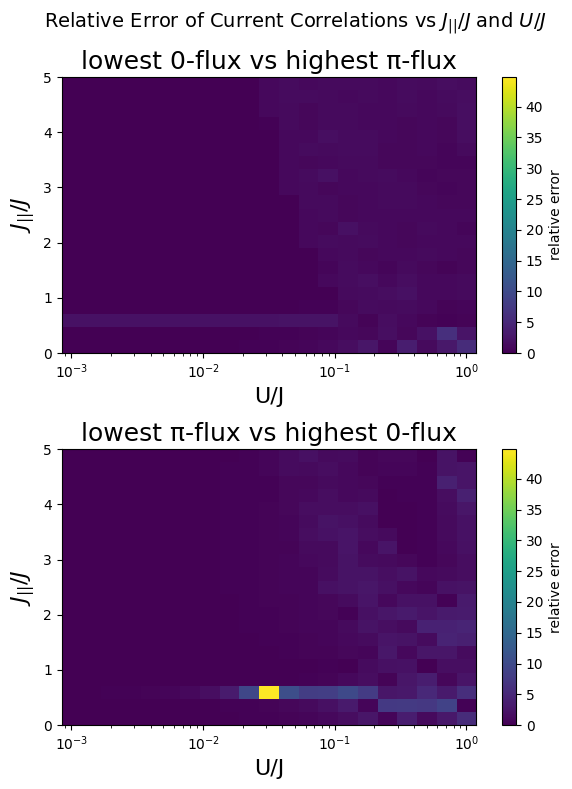

In [72]:
# ---- percent differences ----

eps = 1e-12

A1 = current_correlations_lowest_0_2D
B1 = current_correlations_highest_pi_2D
A2 = current_correlations_lowest_pi_2D
B2 = current_correlations_highest_0_2D

denom1 = np.abs(B1)
denom2 = np.abs(B2)

denom1 = np.where(denom1 < eps, np.nan, denom1)
denom2 = np.where(denom2 < eps, np.nan, denom2)

pct_diff_1 = np.abs(A1 - B1) / denom1
pct_diff_2 = np.abs(A2 - B2) / denom2

# ---- coordinate arrays ----

Jr = np.array(J_ratios)
Ur = np.array(U_ratios)   # log-spaced

# ---- make grid edges for pcolormesh ----
# For Jr (linear)
Jr_edges = np.linspace(Jr[0], Jr[-1], len(Jr) + 1)

# For Ur (log-spaced): use geometric means for cell boundaries
Ur_edges = np.zeros(len(Ur) + 1)
Ur_edges[1:-1] = np.sqrt(Ur[:-1] * Ur[1:])   # geometric midpoints
Ur_edges[0]  = Ur[0]**2 / Ur_edges[1]        # extrapolate lower edge
Ur_edges[-1] = Ur[-1]**2 / Ur_edges[-2]      # extrapolate upper edge

# ---- color limits ----
vmax = np.nanmax([pct_diff_1, pct_diff_2])

# ---- plotting ----

fig, axes = plt.subplots(2,1, figsize=(6, 8))

# Panel 1
pcm0 = axes[0].pcolormesh(Ur_edges, Jr_edges, pct_diff_1,
                          shading='auto', vmin=0, vmax=vmax,
                          cmap='viridis')

axes[0].set_xscale('log')
axes[0].set_title('lowest 0-flux vs highest π-flux', fontsize = 18)
axes[0].set_xlabel('U/J', fontsize=16)
axes[0].set_ylabel('$J_{||}/J$', fontsize=16)

fig.colorbar(pcm0, ax=axes[0], label='relative error')

# Panel 2
pcm1 = axes[1].pcolormesh(Ur_edges, Jr_edges, pct_diff_2,
                          shading='auto', vmin=0, vmax=vmax,
                          cmap='viridis')

axes[1].set_xscale('log')
axes[1].set_title('lowest π-flux vs highest 0-flux', fontsize = 18)
axes[1].set_xlabel('U/J', fontsize=16)
axes[1].set_ylabel('$J_{||}/J$', fontsize=16)

fig.colorbar(pcm1, ax=axes[1], label='relative error')

plt.suptitle('Relative Error of Current Correlations vs $J_{||}/J$ and $U/J$', fontsize = 14)

plt.tight_layout()
plt.show()


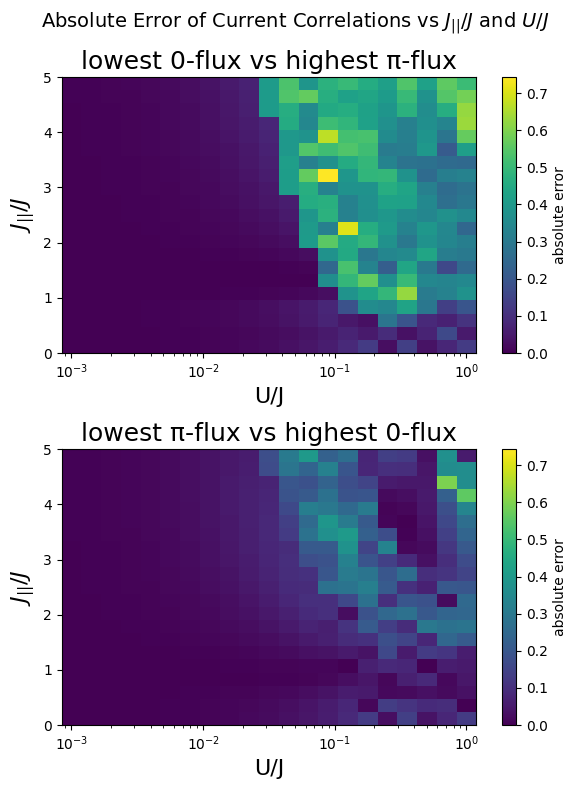

In [73]:
# ---- absolute error ----

eps = 1e-12

A1 = current_correlations_lowest_0_2D
B1 = current_correlations_highest_pi_2D
A2 = current_correlations_lowest_pi_2D
B2 = current_correlations_highest_0_2D

denom1 = np.abs(B1)
denom2 = np.abs(B2)

denom1 = np.where(denom1 < eps, np.nan, denom1)
denom2 = np.where(denom2 < eps, np.nan, denom2)

pct_diff_1 = np.abs(A1 - B1)
pct_diff_2 = np.abs(A2 - B2)

# ---- coordinate arrays ----

Jr = np.array(J_ratios)
Ur = np.array(U_ratios)   # log-spaced

# ---- make grid edges for pcolormesh ----
# For Jr (linear)
Jr_edges = np.linspace(Jr[0], Jr[-1], len(Jr) + 1)

# For Ur (log-spaced): use geometric means for cell boundaries
Ur_edges = np.zeros(len(Ur) + 1)
Ur_edges[1:-1] = np.sqrt(Ur[:-1] * Ur[1:])   # geometric midpoints
Ur_edges[0]  = Ur[0]**2 / Ur_edges[1]        # extrapolate lower edge
Ur_edges[-1] = Ur[-1]**2 / Ur_edges[-2]      # extrapolate upper edge

# ---- color limits ----
vmax = np.nanmax([pct_diff_1, pct_diff_2])

# ---- plotting ----

fig, axes = plt.subplots(2,1, figsize=(6, 8))

# Panel 1
pcm0 = axes[0].pcolormesh(Ur_edges, Jr_edges, pct_diff_1,
                          shading='auto', vmin=0, vmax=vmax,
                          cmap='viridis')

axes[0].set_xscale('log')
axes[0].set_title('lowest 0-flux vs highest π-flux', fontsize = 18)
axes[0].set_xlabel('U/J', fontsize=16)
axes[0].set_ylabel('$J_{||}/J$', fontsize=16)

fig.colorbar(pcm0, ax=axes[0], label='absolute error')

# Panel 2
pcm1 = axes[1].pcolormesh(Ur_edges, Jr_edges, pct_diff_2,
                          shading='auto', vmin=0, vmax=vmax,
                          cmap='viridis')

axes[1].set_xscale('log')
axes[1].set_title('lowest π-flux vs highest 0-flux', fontsize = 18)
axes[1].set_xlabel('U/J', fontsize=16)
axes[1].set_ylabel('$J_{||}/J$', fontsize=16)

fig.colorbar(pcm1, ax=axes[1], label='absolute error')

plt.suptitle('Absolute Error of Current Correlations vs $J_{||}/J$ and $U/J$', fontsize = 14)

plt.tight_layout()
plt.show()
